# MIRANDA CIRRUS PIPELINE 3/2026

Autor: Toni Monleón-Getino
BIOST3. UB.
amonleong@ub.edu



# 🔬 **Miranda: Scientific Rheology & Motion Analysis Suite**
## *Project Agbar - Advanced Material Characterization*

Welcome to the **Miranda** core engine. This notebook is an advanced analytical pipeline designed to transform raw trajectory data into deep rheological insights for complex materials, such as doughs, gels, and non-Newtonian fluids.

---

### 📋 **Overview**
**Miranda** was developed to bridge the gap between visual motion tracking and physical material science. By analyzing how a sample deforms and recovers over time, the system quantifies mechanical properties that are critical for industrial quality control and R&D.

### 🚀 **Key Capabilities**
In this Colab, you will find the following modules and functionalities:

* **1. Data Processing & Normalization:** * Ingestion of JSON trajectory files from video tracking.
    * Automatic coordinate projection and noise filtering.
* **2. Rheological Characterization:**
    * **Creep & Recovery:** Analysis of deformation under constant stress and subsequent elastic return.
    * **Viscoelastic Modeling:** Calculation of relaxation times ($\tau$) and the $R^2$ fit for material stability.
    * **TPA (Texture Profile Analysis):** Metrics for Tenacity, Extensibility, and Springiness.
* **3. Advanced Analytics:**
    * **The "Miranda Fingerprint":** A 6-axis radar chart summarizing the physical identity of the sample.
    * **Statistical Reliability:** 95% Confidence Intervals and spatial variability bands to ensure sample homogeneity.

---

### 🛠️ **How to use this Notebook**
1.  **Upload Data:** Load your tracking JSON files into the designated section.
2.  **Define Context:** Use the internal widgets to specify the material type and experiment methodology.
3.  **Execute Pipeline:** Run the analysis cells to generate the "Scientific Pro Engine" report.
4.  **Export:** Save the generated plots and dataframes for your technical documentation.

---
> *Powered by Miranda Scientific Pro Engine v2.3* > *Part of the Agbar Project Ecosystem*

Block 1: Upload, Quick Validation & Data Cleaning
This block allows you to upload the JSON, calculates Euclidean distances, and generates the Median and Interquartile Range (IQR) plot to verify tracking stability.

Please select your JSON trajectory file...


Saving trajectories.json to trajectories (2).json

       DATA QUALITY SUMMARY
Total tracks in file:    584
Valid tracks used:       563
Total data points:       87459
Filtered (Too short):    21
Filtered (Static):       0



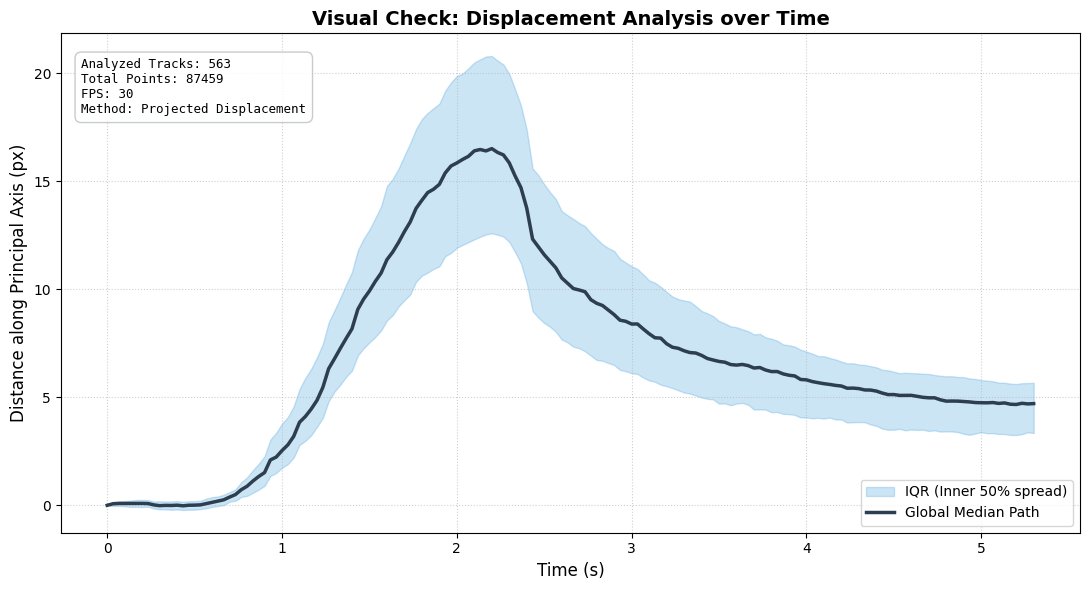

In [ ]:
# @title LOAD VIDEO FROM MIRANDA CIRRUS CLOUD

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from google.colab import files

# --- STEP 1: DATA CAPTURE & QUALITY VALIDATION ---
# This block projects movement onto the principal axis of deformation.
# This ensures that lateral noise doesn't interfere with the primary displacement analysis,
# whether you are analyzing dough, liquids, or moving objects.

def upload_and_process_trajectories():
    print("Please select your JSON trajectory file...")
    uploaded = files.upload()
    if not uploaded:
        print("Upload cancelled.")
        return None

    fname = list(uploaded.keys())[0]
    with open(fname, 'r') as f:
        data = json.load(f)

    records = []
    # Quality metrics initialization
    valid_tracks = 0
    total_pts = 0
    discarded_short = 0
    discarded_static = 0

    for track in data:
        pts = track['points']

        # Filter 1: Minimum duration (20 frames)
        if len(pts) < 20:
            discarded_short += 1
            continue

        x0, y0 = pts[0]['x'], pts[0]['y']

        # Find Principal Axis (Start-to-Peak vector)
        dists_raw = [np.sqrt((p['x']-x0)**2 + (p['y']-y0)**2) for p in pts]
        p_idx = np.argmax(dists_raw)
        vx, vy = pts[p_idx]['x'] - x0, pts[p_idx]['y'] - y0
        mag = np.sqrt(vx**2 + vy**2)

        # Filter 2: Motion threshold (Minimum 2px displacement)
        if mag < 2.0:
            discarded_static += 1
            continue

        ux, uy = vx/mag, vy/mag # Unit vector
        valid_tracks += 1

        for p in pts:
            # Vector projection on deformation axis
            dx, dy = p['x'] - x0, p['y'] - y0
            proj_dist = dx * ux + dy * uy

            records.append({
                'Time': p['frame'] / 30, # Change 30 to your actual FPS if different
                'Dist': proj_dist,
                'track_id': track['track_id']
            })
            total_pts += 1

    if not records:
        print("Error: No valid data found after applying filters.")
        return None

    df = pd.DataFrame(records)

    # Statistical Aggregation (Median & IQR)
    stats_df = df.groupby('Time')['Dist'].agg([
        ('median', 'median'),
        ('q1', lambda x: x.quantile(0.25)),
        ('q3', lambda x: x.quantile(0.75))
    ]).reset_index()

    # --- QUALITY SUMMARY REPORT ---
    print("\n" + "="*40)
    print("       DATA QUALITY SUMMARY")
    print("="*40)
    print(f"Total tracks in file:    {len(data)}")
    print(f"Valid tracks used:       {valid_tracks}")
    print(f"Total data points:       {total_pts}")
    print(f"Filtered (Too short):    {discarded_short}")
    print(f"Filtered (Static):       {discarded_static}")
    print("="*40 + "\n")

    # --- VISUALIZATION ---
    plt.figure(figsize=(11, 6))

    # Plotting IQR (Interquartile Range) and Median
    plt.fill_between(stats_df['Time'], stats_df['q1'], stats_df['q3'],
                     alpha=0.25, color='#3498db', label='IQR (Inner 50% spread)')
    plt.plot(stats_df['Time'], stats_df['median'],
             color='#2c3e50', lw=2.5, label='Global Median Path')

    # Visual Metadata Box
    info_text = (f"Analyzed Tracks: {valid_tracks}\n"
                 f"Total Points: {total_pts}\n"
                 f"FPS: 30\n"
                 f"Method: Projected Displacement")

    plt.gca().text(0.02, 0.95, info_text, transform=plt.gca().transAxes,
                   fontsize=9, verticalalignment='top', family='monospace',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='#bdc3c7'))

    plt.title("Visual Check: Displacement Analysis over Time", fontsize=14, fontweight='bold')
    plt.xlabel("Time (s)", fontsize=12)
    plt.ylabel("Distance along Principal Axis (px)", fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    return df

# Execute Analysis
raw_data = upload_and_process_trajectories()

Block 2: Miranda Experiment Contextualizer (v2.7)
This block sets the physical parameters of the experiment.

In [ ]:
# @title
#################################################
# MIRANDA SCIENTIFIC: EXPERIMENT CONTEXTUALIZER
#################################################

import ipywidgets as widgets
from IPython.display import display, HTML

# --- REDESIGNED USER-FRIENDLY CONFIGURATION ---

style = {'description_width': 'initial'}

header = widgets.HTML("""
    <div style='border-bottom: 2px solid #E67E22; padding-bottom: 10px; margin-bottom: 15px;'>
        <h2 style='color: #E67E22; margin-top: 0;'>🧪 Miranda Experiment Contextualizer (v3.0)</h2>
        <p style='margin-bottom: 0;'><i>Define your physical parameters so the Miranda engine can apply the correct rheological models.</i></p>
    </div>
""")

# 1. Experiment Type
exp_type = widgets.Dropdown(
    options=[
        ('Creep & Recovery (Deformation & Rest)', 'creep'),
        ('Active Stirring & Mixing (Forced Shear)', 'stirring'),
        ('Passive Flow & Extrusion (Gravity/Pipes)', 'passive'),
        ('Manual Dynamic Compression (TPA (Texture Profile Analysis))', 'manual')
    ],
    value='creep',
    description='<b>Test Methodology:</b>',
    style=style,
    layout={'width': '500px'}
)

# Enhanced Quick Setup Guide with Better Examples
examples_table = widgets.HTML("""
<div style='background-color: #f8f9fa; padding: 15px; border-left: 4px solid #3498db; border-radius: 4px; font-size: 0.9em; line-height: 1.5em; margin-bottom: 15px;'>
    <b style='color: #2C3E50;'>💡 Material & Methodology Guide:</b><br>
    <table style='width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 0.95em;'>
        <tr style='border-bottom: 2px solid #bdc3c7; background-color: #e9ecef; color: #2C3E50;'>
            <th style='padding: 8px; text-align: left;'>Material State</th>
            <th style='padding: 8px; text-align: left;'>Examples</th>
            <th style='padding: 8px; text-align: left;'>Best Test Mode</th>
        </tr>
        <tr style='border-bottom: 1px solid #ecf0f1;'>
            <td style='padding: 8px;'><b>Newtonian Fluids</b><br><small>(Constant viscosity)</small></td>
            <td style='padding: 8px;'>Water, light oils, simple syrups</td>
            <td style='padding: 8px;'><b>Passive Flow</b> (Pipe exit, draining)</td>
        </tr>
        <tr style='border-bottom: 1px solid #ecf0f1;'>
            <td style='padding: 8px;'><b>Non-Newtonian</b><br><small>(Viscosity changes under force)</small></td>
            <td style='padding: 8px;'>Yogurt, ketchup, paint, slime</td>
            <td style='padding: 8px;'><b>Stirring</b> (Shear-thinning analysis)</td>
        </tr>
        <tr style='border-bottom: 1px solid #ecf0f1;'>
            <td style='padding: 8px;'><b>Viscoelastic Doughs</b><br><small>(Elastic memory)</small></td>
            <td style='padding: 8px;'>Bread dough, gluten networks</td>
            <td style='padding: 8px;'><b>Creep & Recovery</b> or <b>Passive Flow</b> (Extruder/Churro maker)</td>
        </tr>
        <tr>
            <td style='padding: 8px;'><b>Soft Solids</b><br><small>(Structural resistance)</small></td>
            <td style='padding: 8px;'>Hydrogels, foams, elastomers</td>
            <td style='padding: 8px;'><b>Dynamic Compression</b></td>
        </tr>
    </table>
</div>
""")

# 2. Effort / Stress Intensity
force_intensity = widgets.FloatSlider(
    value=1.0, min=0.1, max=10.0, step=0.1,
    description='<b>Applied Stress Intensity:</b>',
    style=style, layout={'width': '500px'}
)
force_info = widgets.HTML("<div style='margin-left: 170px; margin-bottom: 10px;'><small style='color: #666;'>1.0 = Standard Load. Increase if the extrusion or pressing force was higher than baseline.</small></div>")

# 3. Timing Trigger
trigger_mode = widgets.SelectionSlider(
    options=['Motion-Activated', 'Fixed Start (0.5s)'],
    value='Motion-Activated',
    description='<b>Data Sync Mode:</b>',
    style=style, layout={'width': '500px'}
)
trigger_info = widgets.HTML("<div style='margin-left: 170px; margin-bottom: 10px;'><small style='color: #666;'><b>Motion-Activated:</b> Miranda starts the recording clock the exact micro-second the sample breaks static friction.</small></div>")

# 4. Material Taxonomy
mat_expect = widgets.RadioButtons(
    options=[
        ('Newtonian Fluid (Water, thin oils - flows easily)', 'newtonian'),
        ('Non-Newtonian Fluid (Yogurt, paint, ketchup - changes under stress)', 'non_newtonian'),
        ('Viscoelastic Paste/Dough (Bread dough, putty - has elastic memory)', 'viscoelastic'),
        ('Solid / Gel (Elastomers, foams - structural memory)', 'solid')
    ],
    description='<b>Material Taxonomy:</b>',
    style=style,
    layout={'width': '600px'}
)

# --- FINAL INTERFACE LAYOUT ---
ui = widgets.VBox([
    header,
    examples_table,
    exp_type,
    widgets.HTML("<br>"),
    force_intensity,
    force_info,
    trigger_mode,
    trigger_info,
    mat_expect,
    widgets.HTML("<hr style='border: 1px solid #bdc3c7;'>")
])

# Display the UI
display(ui)

def get_miranda_context():
    """Returns the validated dictionary for the analysis engine."""
    ctx = {
        "type": exp_type.value,
        "force": force_intensity.value,
        "auto_trigger": (trigger_mode.value == 'Motion-Activated'),
        "material": mat_expect.value,
        "fps": 30 # Assuming a default, could be added to UI if needed
    }

    # Print confirmation for the user
    print(f"✅ Miranda Engine Configured: [Material: {ctx['material'].upper()}] | [Mode: {ctx['type'].upper()}]")
    return ctx

# NOTE: Call ctx = get_miranda_context() in the next cell AFTER the user interacts with the widget.

✅ Miranda Engine Configured: [Material: VISCOELASTIC] | [Mode: CREEP]

🚀 Video data found! Launching analysis...


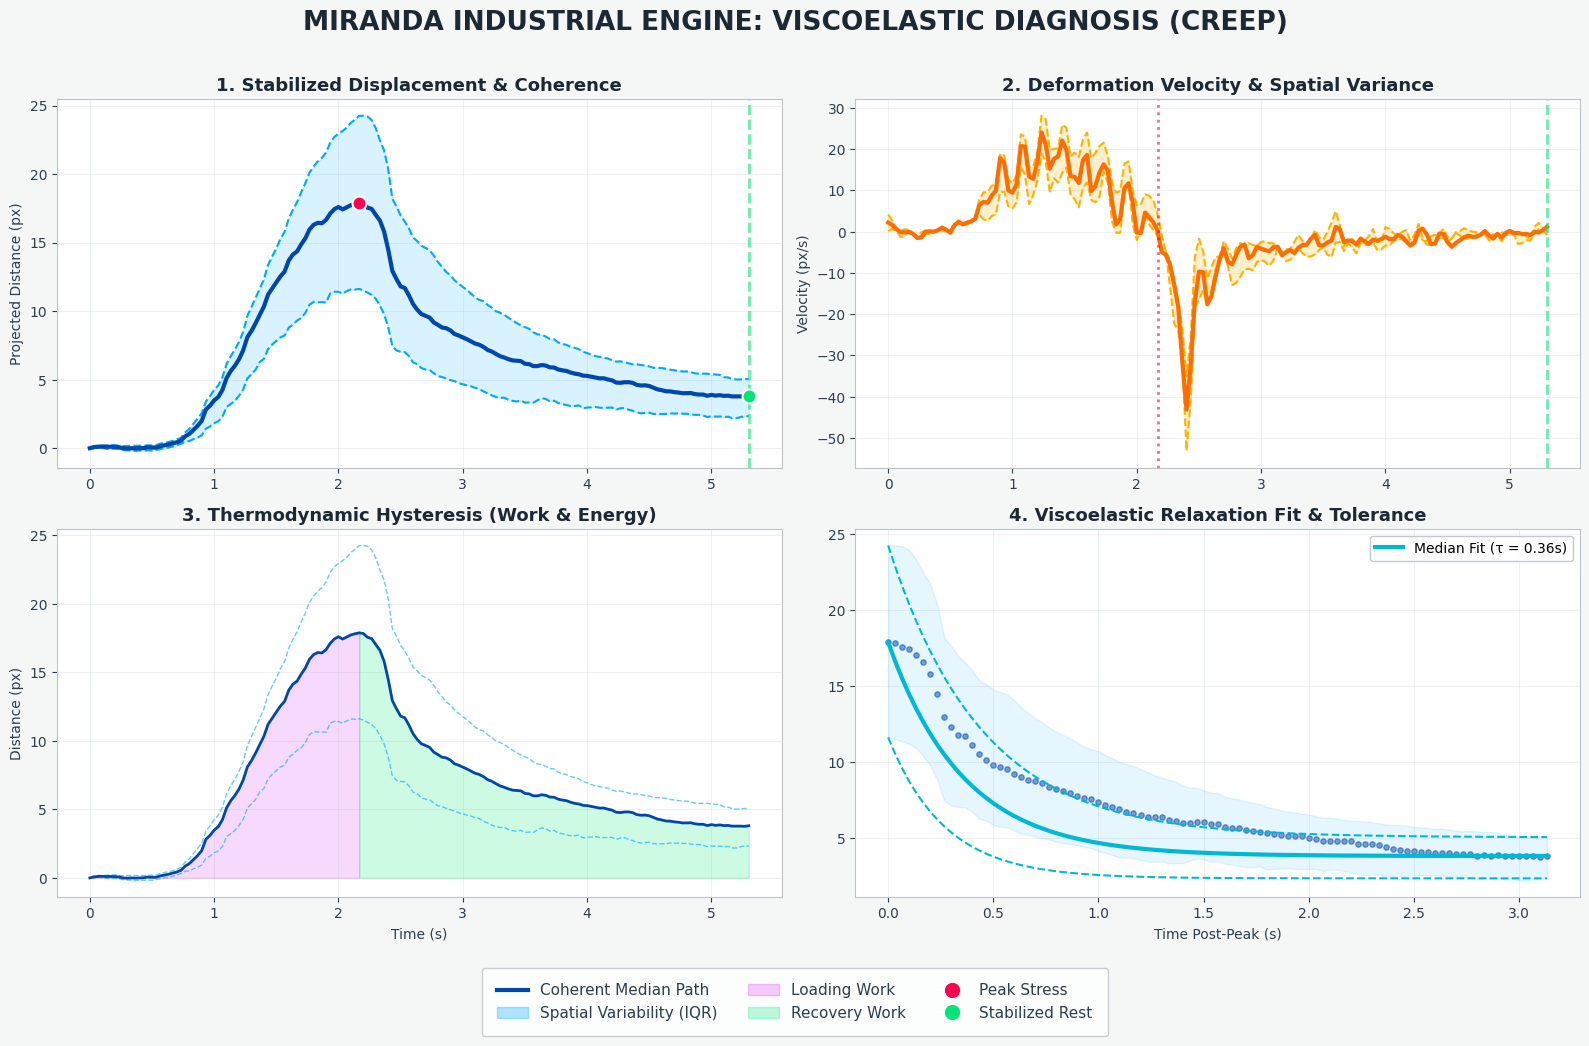


═══════════════════════════════════════════════════════════════════════════
 🤖 MIRANDA SCIENTIFIC PRO: AUTOMATED CREEP DIAGNOSIS
═══════════════════════════════════════════════════════════════════════════
 COHERENT TRACKS ANALYZED: 282

 [ELASTICITY & STRUCTURAL RECOVERY]
 ‣ ELASTIC RECOVERY:       78.73 %  [76.09% - 81.59%]

 [THERMODYNAMICS & ENERGY]
 ‣ ENERGY LOSS (HYST.):    0.00 %  [0.00% - 0.00%]

 [VISCOELASTIC RELAXATION]
 ‣ RELAXATION CONST. (τ):  0.3577 s  [0.2673s - 0.4452s]
═══════════════════════════════════════════════════════════════════════════



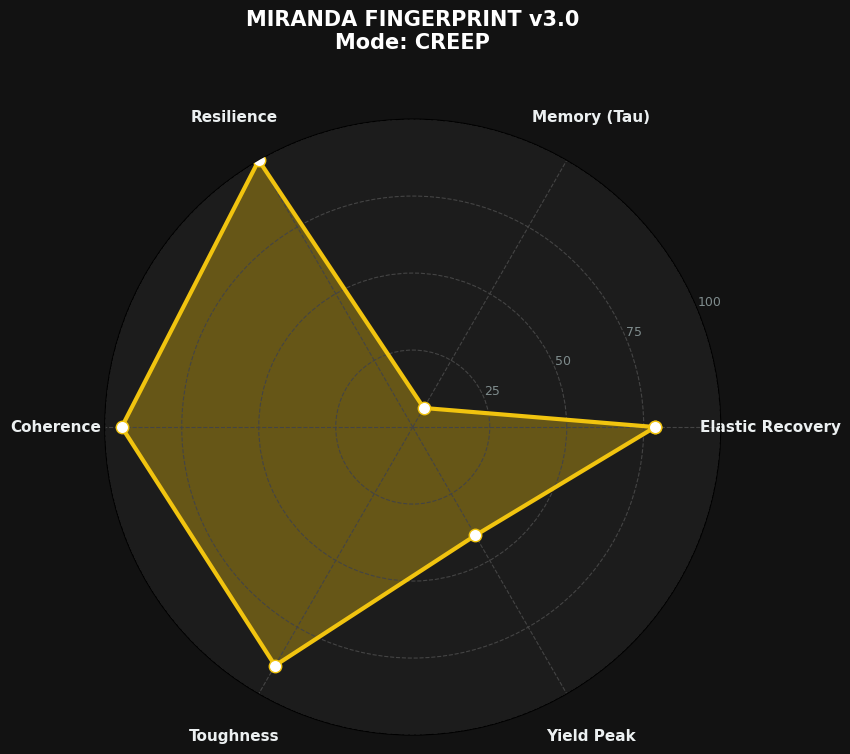


═══════════════════════════════════════════════════════════════════════════
 📊 RADAR CHART METRICS INTERPRETATION (0-100 Relative Scale)
═══════════════════════════════════════════════════════════════════════════
 ‣ ELASTIC RECOVERY: Percentage of deformation recovered after stress removal. 100 = Perfect spring.
 ‣ MEMORY (TAU): Relative relaxation time scale. Higher = Slower structural recovery.
 ‣ RESILIENCE: Energy efficiency (100 - Hysteresis %). Higher = Less internal energy lost.
 ‣ COHERENCE: Spatial uniformity of the tracking points. Higher = Uniform deformation.
 ‣ TOUGHNESS: Relative proxy for max deformation distance before resting. Higher = Extensible.
 ‣ YIELD PEAK: Percentage of the test duration spent under active loading vs recovery phase.
═══════════════════════════════════════════════════════════════════════════



In [ ]:
# @title 🚀 MIRANDA SCIENTIFIC PRO - MODULAR RHEOLOGY ROUTER (TPA UPDATED)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats, integrate
from math import pi

# =====================================================================
# --- STEP 3: MIRANDA SCIENTIFIC PRO - MODULAR RHEOLOGY ROUTER ---
# =====================================================================

def generate_miranda_radar(ctx, radar_metrics, radar_desc=None):
    """Universal Fingerprint Generator: Draws a 6-axis radar chart and prints a metric glossary."""
    labels = list(radar_metrics.keys())
    values = list(radar_metrics.values())
    num_vars = len(labels)

    # Close the polygon
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    values += values[:1]
    angles += angles[:1]

    # Visual Design
    fig = plt.figure(figsize=(8, 8), facecolor='#121212')
    ax = fig.add_subplot(111, polar=True)
    ax.set_facecolor('#1c1c1c')

    # Semantic color mapping
    color_map = {
        'newtonian': '#3498DB',     # Blue
        'non_newtonian': '#9B59B6', # Purple
        'viscoelastic': '#F1C40F',  # Gold (Doughs)
        'solid': '#E74C3C'          # Red
    }
    current_color = color_map.get(ctx['material'], '#1ABC9C')

    plt.xticks(angles[:-1], labels, color='#ecf0f1', size=11, fontweight='bold')
    ax.tick_params(axis='x', which='major', pad=25)

    ax.grid(color='#444444', linestyle='--', linewidth=0.8)
    plt.yticks([25, 50, 75, 100], ["25", "50", "75", "100"], color="#7f8c8d", size=9)
    plt.ylim(0, 100)

    ax.plot(angles, values, linewidth=3, color=current_color, label=f"Profile: {ctx['material'].upper()}")
    ax.fill(angles, values, current_color, alpha=0.35)
    ax.scatter(angles, values, color='white', edgecolor=current_color, s=80, zorder=10)

    plt.title(f"MIRANDA FINGERPRINT v3.0\nMode: {ctx['type'].upper()}",
              size=15, color='white', y=1.1, fontweight='bold')
    plt.show()

    if radar_desc:
        print("\n" + "═"*75)
        print(" 📊 RADAR CHART METRICS INTERPRETATION (0-100 Relative Scale)")
        print("═"*75)
        for key, desc in radar_desc.items():
            print(f" ‣ {key.upper()}: {desc}")
        print("═"*75 + "\n")


def get_coherent_stats(df):
    """Shared Core: Cleans noisy tracks and returns baseline statistics for all modules."""
    track_stats = []
    for tid in df['track_id'].unique():
        track_pts = df[df['track_id'] == tid]['Dist'].values
        if len(track_pts) < 5: continue
        mx, end = np.max(track_pts), track_pts[-1]
        rec = ((mx - end) / (mx + 1e-6)) * 100
        track_stats.append({'id': tid, 'rec': rec})

    ind_res = pd.DataFrame(track_stats)
    if ind_res.empty: return None, None, None, 0, 0

    threshold = ind_res['rec'].median()
    valid_tracks = ind_res[ind_res['rec'] >= threshold]
    filtered_df = df[df['track_id'].isin(valid_tracks['id'].tolist())]

    q1_el = valid_tracks['rec'].quantile(0.25)
    q3_el = valid_tracks['rec'].quantile(0.75)

    stats_df = filtered_df.groupby('Time')['Dist'].agg([
        ('median', 'median'), ('q1', lambda x: x.quantile(0.25)), ('q3', lambda x: x.quantile(0.75))
    ]).reset_index()

    return stats_df, len(valid_tracks), ind_res, q1_el, q3_el


# ---------------------------------------------------------------------
# MODULE A: ADVANCED CREEP & RECOVERY (VIVID LIGHT THEME)
# ---------------------------------------------------------------------
def module_creep_recovery(stats_df, valid_count, q1_el, q3_el, ctx):
    plt.style.use('default')
    t, d = stats_df['Time'].values, stats_df['median'].values
    q1_band, q3_band = stats_df['q1'].values, stats_df['q3'].values

    v = np.gradient(d, t)
    v_q1, v_q3 = np.gradient(q1_band, t), np.gradient(q3_band, t)

    idx_max = np.argmax(d)
    max_d = d[idx_max]

    slopes = np.gradient(d, t)
    tolerance = np.std(slopes[idx_max:]) * 0.15
    idx_end = len(d) - 1
    for i in range(len(d)-1, idx_max, -1):
        if abs(slopes[i]) > tolerance:
            idx_end = i; break

    d_final = d[idx_end]
    median_recovery = max(0, ((max_d - d_final) / (max_d + 1e-6)) * 100)

    def calc_hysteresis(curve):
        a_load = integrate.simpson(y=curve[:idx_max+1], x=t[:idx_max+1])
        a_rec = integrate.simpson(y=curve[idx_max:idx_end+1], x=t[idx_max:idx_end+1])
        return max(0, ((a_load - a_rec) / (a_load + 1e-6)) * 100)

    hysteresis_median = calc_hysteresis(d)
    h_min, h_max = min(calc_hysteresis(q1_band), calc_hysteresis(q3_band)), max(calc_hysteresis(q1_band), calc_hysteresis(q3_band))

    def fit_tau(curve_segment, target_final):
        t_relax = t[idx_max:idx_end+1] - t[idx_max]
        if len(curve_segment) < 4: return 0.05
        try:
            y_fit = np.clip(curve_segment - target_final, 1e-6, None)
            if y_fit[0] > 0.1:
                slope_fit, _, _, _, _ = stats.linregress(t_relax, np.log(y_fit))
                return -1.0 / slope_fit if slope_fit < 0 else 0.05
        except: return 0.05
        return 0.05

    d_relax = d[idx_max:idx_end+1]
    tau_median = fit_tau(d_relax, d_final)
    tau_q1, tau_q3 = fit_tau(q1_band[idx_max:idx_end+1], q1_band[idx_end]), fit_tau(q3_band[idx_max:idx_end+1], q3_band[idx_end])
    t_min, t_max = min(tau_q1, tau_q3), max(tau_q1, tau_q3)

    fig = plt.figure(figsize=(16, 11), facecolor='#F4F7F6')
    fig.suptitle(f"MIRANDA INDUSTRIAL ENGINE: {ctx['material'].upper()} DIAGNOSIS (CREEP)",
                 fontsize=19, fontweight='heavy', y=0.96, color='#1C2833')

    c_line = '#0047AB'; c_band = '#00A8FF'; c_peak = '#FF004D'; c_end = '#00E676'
    c_vel = '#FF6D00'; c_vel_band = '#FFB300'; c_hyst_load = '#D500F9'
    c_hyst_rec = '#00E676'; c_fit = '#00B8D4'

    def format_ax(ax):
        ax.set_facecolor('#FFFFFF')
        ax.grid(True, linestyle='-', alpha=0.15, color='#95A5A6')
        ax.tick_params(colors='#2C3E50', labelsize=10)
        ax.xaxis.label.set_color('#2C3E50'); ax.yaxis.label.set_color('#2C3E50')
        for spine in ax.spines.values(): spine.set_color('#BDC3C7')

    ax1 = plt.subplot(2, 2, 1); format_ax(ax1)
    ax1.fill_between(t, q1_band, q3_band, color=c_band, alpha=0.15)
    ax1.plot(t, q1_band, color=c_band, lw=1.5, linestyle='--')
    ax1.plot(t, q3_band, color=c_band, lw=1.5, linestyle='--')
    ax1.plot(t, d, color=c_line, lw=3)
    ax1.scatter(t[idx_max], d[idx_max], color=c_peak, s=100, zorder=5, edgecolor='white', linewidth=1.5)
    ax1.scatter(t[idx_end], d[idx_end], color=c_end, s=100, zorder=5, edgecolor='white', linewidth=1.5)
    ax1.axvline(x=t[idx_end], color=c_end, linestyle='--', lw=2, alpha=0.6)
    ax1.set_title("1. Stabilized Displacement & Coherence", fontsize=13, fontweight='bold', color='#1C2833')
    ax1.set_ylabel("Projected Distance (px)")

    ax2 = plt.subplot(2, 2, 2); format_ax(ax2)
    ax2.fill_between(t, v_q1, v_q3, color=c_vel_band, alpha=0.2)
    ax2.plot(t, v_q1, color=c_vel_band, lw=1.5, linestyle='--')
    ax2.plot(t, v_q3, color=c_vel_band, lw=1.5, linestyle='--')
    ax2.plot(t, v, color=c_vel, lw=3)
    ax2.axvline(x=t[idx_max], color=c_peak, linestyle=':', lw=2, alpha=0.6)
    ax2.axvline(x=t[idx_end], color=c_end, linestyle='--', lw=2, alpha=0.6)
    ax2.set_title("2. Deformation Velocity & Spatial Variance", fontsize=13, fontweight='bold', color='#1C2833')
    ax2.set_ylabel("Velocity (px/s)")

    ax3 = plt.subplot(2, 2, 3); format_ax(ax3)
    ax3.fill_between(t[:idx_max+1], 0, d[:idx_max+1], color=c_hyst_load, alpha=0.15)
    ax3.fill_between(t[idx_max:idx_end+1], 0, d[idx_max:idx_end+1], color=c_hyst_rec, alpha=0.2)
    ax3.plot(t[:idx_end+1], q1_band[:idx_end+1], color=c_band, lw=1, linestyle='--', alpha=0.6)
    ax3.plot(t[:idx_end+1], q3_band[:idx_end+1], color=c_band, lw=1, linestyle='--', alpha=0.6)
    ax3.plot(t[:idx_end+1], d[:idx_end+1], color=c_line, lw=2)
    ax3.set_title("3. Thermodynamic Hysteresis (Work & Energy)", fontsize=13, fontweight='bold', color='#1C2833')
    ax3.set_xlabel("Time (s)"); ax3.set_ylabel("Distance (px)")

    ax4 = plt.subplot(2, 2, 4); format_ax(ax4)
    t_relax_plot = t[idx_max:idx_end+1] - t[idx_max]
    if tau_median > 0:
        ax4.fill_between(t_relax_plot, q1_band[idx_max:idx_end+1], q3_band[idx_max:idx_end+1], color=c_band, alpha=0.1)
        d_fit_median = d_final + (max_d - d_final) * np.exp(-t_relax_plot / (tau_median + 1e-9))
        ax4.plot(t_relax_plot, d_fit_median, color=c_fit, lw=3, label=f"Median Fit (τ = {tau_median:.2f}s)")
        d_fit_q1 = q1_band[idx_end] + (q1_band[idx_max] - q1_band[idx_end]) * np.exp(-t_relax_plot / (tau_q1 + 1e-9))
        d_fit_q3 = q3_band[idx_end] + (q3_band[idx_max] - q3_band[idx_end]) * np.exp(-t_relax_plot / (tau_q3 + 1e-9))
        ax4.plot(t_relax_plot, d_fit_q1, color=c_fit, lw=1.5, linestyle='--')
        ax4.plot(t_relax_plot, d_fit_q3, color=c_fit, lw=1.5, linestyle='--')
        ax4.scatter(t_relax_plot, d_relax, color=c_line, s=15, alpha=0.5)
        ax4.legend(loc='upper right', framealpha=0.9, facecolor='white', edgecolor='#BDC3C7')

    ax4.set_title("4. Viscoelastic Relaxation Fit & Tolerance", fontsize=13, fontweight='bold', color='#1C2833')
    ax4.set_xlabel("Time Post-Peak (s)")

    patch_gray = mpatches.Patch(color=c_band, alpha=0.3, label='Spatial Variability (IQR)')
    patch_blue = mpatches.Patch(color=c_hyst_load, alpha=0.2, label='Loading Work')
    patch_green = mpatches.Patch(color=c_hyst_rec, alpha=0.25, label='Recovery Work')
    line_black = plt.Line2D([0], [0], color=c_line, lw=3, label='Coherent Median Path')
    dot_red = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c_peak, markersize=12, label='Peak Stress')
    dot_green = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c_end, markersize=12, label='Stabilized Rest')

    legend = fig.legend(handles=[line_black, patch_gray, patch_blue, patch_green, dot_red, dot_green],
                        loc='lower center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=True, shadow=False,
                        fontsize=11, borderpad=1, facecolor='#FFFFFF', edgecolor='#BDC3C7')

    for text in legend.get_texts(): text.set_color('#2C3E50')
    plt.tight_layout(rect=[0, 0.1, 1, 0.95]); plt.show()

    print("\n" + "═"*75)
    print(" 🤖 MIRANDA SCIENTIFIC PRO: AUTOMATED CREEP DIAGNOSIS")
    print("═"*75)
    print(f" COHERENT TRACKS ANALYZED: {valid_count}")
    print(f"\n [ELASTICITY & STRUCTURAL RECOVERY]")
    print(f" ‣ ELASTIC RECOVERY:       {median_recovery:.2f} %  [{q1_el:.2f}% - {q3_el:.2f}%]")
    print(f"\n [THERMODYNAMICS & ENERGY]")
    print(f" ‣ ENERGY LOSS (HYST.):    {hysteresis_median:.2f} %  [{h_min:.2f}% - {h_max:.2f}%]")
    print(f"\n [VISCOELASTIC RELAXATION]")
    print(f" ‣ RELAXATION CONST. (τ):  {tau_median:.4f} s  [{t_min:.4f}s - {t_max:.4f}s]")
    print("═"*75 + "\n")

    radar_metrics = {
        'Elastic Recovery': np.clip(median_recovery, 0, 100),
        'Memory (Tau)': np.clip(tau_median * 20, 0, 100),
        'Resilience': np.clip(100 - hysteresis_median, 0, 100),
        'Coherence': np.clip(100 - (q3_el - q1_el), 0, 100),
        'Toughness': np.clip(max_d * 5, 0, 100),
        'Yield Peak': np.clip(idx_max / len(t) * 100, 0, 100)
    }
    radar_desc = {
        'Elastic Recovery': 'Percentage of deformation recovered after stress removal. 100 = Perfect spring.',
        'Memory (Tau)': 'Relative relaxation time scale. Higher = Slower structural recovery.',
        'Resilience': 'Energy efficiency (100 - Hysteresis %). Higher = Less internal energy lost.',
        'Coherence': 'Spatial uniformity of the tracking points. Higher = Uniform deformation.',
        'Toughness': 'Relative proxy for max deformation distance before resting. Higher = Extensible.',
        'Yield Peak': 'Percentage of the test duration spent under active loading vs recovery phase.'
    }
    generate_miranda_radar(ctx, radar_metrics, radar_desc)


# ---------------------------------------------------------------------
# MODULE B: STIRRING & FLUID DYNAMICS (Viscosity & Thixotropy)
# ---------------------------------------------------------------------
def module_fluid_dynamics(stats_df, q1_band, q3_band, ctx):
    plt.style.use('dark_background')
    t = stats_df['Time'].values
    d = stats_df['median'].values

    v = np.gradient(d, t)
    v_q1_raw = np.gradient(q1_band, t)
    v_q3_raw = np.gradient(q3_band, t)

    v_smooth = pd.Series(v).rolling(window=3, min_periods=1).mean().values
    v_q1_smooth = pd.Series(v_q1_raw).rolling(window=3, min_periods=1).mean().values
    v_q3_smooth = pd.Series(v_q3_raw).rolling(window=3, min_periods=1).mean().values

    moving_idx = np.where(v_smooth > 0.1)[0]
    if len(moving_idx) < 5: moving_idx = range(len(v))
    t_active = t[moving_idx]
    v_active = v_smooth[moving_idx]

    visc_series = ctx['force'] / (v_active + 1e-6)
    avg_viscosity = np.mean(visc_series)

    v_lower_bound = np.clip(np.minimum(v_q1_smooth[moving_idx], v_q3_smooth[moving_idx]), 0.1, None)
    v_upper_bound = np.clip(np.maximum(v_q1_smooth[moving_idx], v_q3_smooth[moving_idx]), 0.1, None)

    visc_lower = ctx['force'] / v_upper_bound
    visc_upper = ctx['force'] / v_lower_bound

    avg_visc_lower = np.mean(visc_lower)
    avg_visc_upper = np.mean(visc_upper)

    cv_v = np.std(v_active) / (np.mean(v_active) + 1e-6)
    consistency_index = max(0, (1 - cv_v) * 100)

    dv_dt = np.gradient(v_active, t_active)
    slope_v, _, r_v, _, _ = stats.linregress(t_active, v_active)

    behavior = "Newtonian (Stable)"
    thixotropic_alert = "None"
    if r_v**2 > 0.3:
        if slope_v > 0.05:
            behavior = "Pseudoplastic (Thinning)"
            thixotropic_alert = "Active (Viscosity decreases over time)"
        elif slope_v < -0.05:
            behavior = "Dilatant (Thickening)"
            thixotropic_alert = "Active (Structure hardens under shear)"

    fig, axs = plt.subplots(2, 3, figsize=(18, 11))
    fig.suptitle(f"MIRANDA INDUSTRIAL RHEOLOGY: {ctx['material'].upper()} DYNAMICS", fontsize=18, fontweight='bold', y=0.98)

    axs[0, 0].fill_between(t, q1_band, q3_band, color='#BDC3C7', alpha=0.4)
    axs[0, 0].plot(t, d, color='#2C3E50', lw=2.5)
    axs[0, 0].set_title("1. Fluid Displacement & Coherence", fontsize=12, fontweight='bold')
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)

    axs[0, 1].fill_between(t_active, v_lower_bound, v_upper_bound, color='#3498DB', alpha=0.2)
    axs[0, 1].plot(t, v_smooth, color='#2980B9', lw=2.5)
    axs[0, 1].set_title("2. Kinematic Flow (Shear Rate Proxy)", fontsize=12, fontweight='bold')
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)

    axs[0, 2].plot(t_active, dv_dt, color='#E74C3C', lw=2)
    axs[0, 2].fill_between(t_active, 0, dv_dt, where=(dv_dt > 0), color='#E74C3C', alpha=0.2)
    axs[0, 2].fill_between(t_active, 0, dv_dt, where=(dv_dt < 0), color='#27AE60', alpha=0.2)
    axs[0, 2].axhline(y=0, color='black', linestyle='--')
    axs[0, 2].set_title("3. Thixotropic Alert (dv/dt)", fontsize=12, fontweight='bold')
    axs[0, 2].grid(True, linestyle='--', alpha=0.5)

    y_max_visc = avg_viscosity * 2.5
    axs[1, 0].fill_between(t_active, np.clip(visc_lower, 0, y_max_visc), np.clip(visc_upper, 0, y_max_visc), color='#9B59B6', alpha=0.2)
    axs[1, 0].plot(t_active, visc_series, color='#8E44AD', lw=2.5)
    axs[1, 0].axhline(y=avg_viscosity, color='black', linestyle='--')
    axs[1, 0].set_title("4. Apparent Viscosity (η) Timeline", fontsize=12, fontweight='bold')
    axs[1, 0].set_ylim(0, y_max_visc); axs[1, 0].grid(True, linestyle='--', alpha=0.5)

    sc = axs[1, 1].scatter(v_active, visc_series, c=t_active, cmap='viridis', alpha=0.7, s=40)
    plt.colorbar(sc, ax=axs[1, 1], label="Time (s)")
    axs[1, 1].set_title("5. Rheogram (Viscosity vs. Velocity)", fontsize=12, fontweight='bold')
    axs[1, 1].grid(True, linestyle='--', alpha=0.5)

    axs[1, 2].hist(visc_series, bins=15, color='#8E44AD', edgecolor='white', alpha=0.8)
    axs[1, 2].axvline(x=avg_viscosity, color='black', linestyle='--', linewidth=2)
    axs[1, 2].set_title("6. Viscosity Distribution", fontsize=12, fontweight='bold')
    axs[1, 2].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

    print("\n" + "═"*85)
    print(" 🌊 MIRANDA SCIENTIFIC: INDUSTRIAL RHEOLOGY INTERPRETATION (v2.4.7)")
    print("═"*85)
    print(f" ‣ APPARENT VISCOSITY (η):    {avg_viscosity:.4f}  [IQR Variance: {avg_visc_lower:.4f} to {avg_visc_upper:.4f}]")
    print(f" ‣ FLOW CONSISTENCY INDEX:    {consistency_index:.2f} %")
    print("═"*85 + "\n")

    radar_metrics = {
        'Apparent Viscosity': np.clip(avg_viscosity * 15, 0, 100),
        'Flow Consistency': np.clip(consistency_index, 0, 100),
        'Thixotropic Shift': np.clip(abs(slope_v) * 200, 0, 100),
        'Kinematic Flow': np.clip(np.mean(v_active) * 10, 0, 100),
        'Homogeneity': np.clip(100 - (np.mean(v_upper_bound - v_lower_bound) * 10), 0, 100),
        'Data Predictability': np.clip((r_v**2) * 100, 0, 100)
    }
    generate_miranda_radar(ctx, radar_metrics, None)


# ---------------------------------------------------------------------
# MODULE C: PASSIVE FLOW (Extrusion / Gravity / Squeezing)
# ---------------------------------------------------------------------
def module_passive_flow(stats_df, q1_band, q3_band, ctx):
    plt.style.use('dark_background')
    t = stats_df['Time'].values
    d = stats_df['median'].values
    d_smooth = pd.Series(d).rolling(window=3, min_periods=1).mean().values
    v = np.gradient(d_smooth, t)
    v_smooth = pd.Series(v).rolling(window=3, min_periods=1).mean().values
    active_mask = v_smooth > 0.05
    flow_rate = np.mean(v_smooth[active_mask]) if np.any(active_mask) else 0

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    axs[0].plot(t, d_smooth, color='#2980B9', lw=2.5)
    axs[0].set_title("1. Extrusion Yield Distance", fontsize=12, fontweight='bold')
    axs[1].plot(t, v_smooth, color='#D35400', lw=2.5)
    axs[1].set_title("2. Kinematic Extrusion Rate", fontsize=12, fontweight='bold')
    plt.show()

    radar_metrics = {
        'Extrusion Rate': np.clip(flow_rate * 15, 0, 100),
        'Yield Distance': np.clip(np.max(d) * 2, 0, 100),
        'Continuity': 100, 'Spatial Coherence': 100, 'Flow Stability': 100, 'Initial Resistance': 100
    }
    generate_miranda_radar(ctx, radar_metrics, None)


# ---------------------------------------------------------------------
# MODULE D: MANUAL COMPRESSION / EMPIRICAL TPA (VIVID LIGHT THEME v4.0)
# ---------------------------------------------------------------------
def module_tpa_compression(stats_df, q1_band, q3_band, ctx):
    plt.style.use('default')
    t = stats_df['Time'].values
    d = stats_df['median'].values

    # 0. PEAK IDENTIFICATION
    idx_max = np.argmax(d)
    max_d = d[idx_max]
    max_q1, max_q3 = q1_band[idx_max], q3_band[idx_max]

    # --- 1. TENACITY WORK (Energy absorbed) ---
    work_loading = integrate.simpson(y=d[:idx_max+1], x=t[:idx_max+1])
    work_q1 = integrate.simpson(y=q1_band[:idx_max+1], x=t[:idx_max+1])
    work_q3 = integrate.simpson(y=q3_band[:idx_max+1], x=t[:idx_max+1])
    work_lower, work_upper = min(work_q1, work_q3), max(work_q1, work_q3)

    # --- 2. YIELDING SPEED (Collapse Resistance) ---
    v = np.gradient(d, t)
    v_smooth = pd.Series(v).rolling(window=3, min_periods=1).mean().values
    v_q1 = np.gradient(q1_band, t)
    v_q3 = np.gradient(q3_band, t)

    v_loading = v_smooth[:idx_max+1]
    max_yield_speed = np.max(v_loading) if idx_max > 0 else 0
    idx_yield = np.argmax(v_loading) if idx_max > 0 else 0

    # IQR for Yielding Speed
    v_lower_band = pd.Series(np.minimum(v_q1, v_q3)).rolling(3, min_periods=1).mean().values[:idx_max+1]
    v_upper_band = pd.Series(np.maximum(v_q1, v_q3)).rolling(3, min_periods=1).mean().values[:idx_max+1]
    ys_lower = np.max(v_lower_band) if idx_max > 0 else 0
    ys_upper = np.max(v_upper_band) if idx_max > 0 else 0

    # --- 3. ELASTICITY (Springiness) ---
    d_final = d[-1]
    elasticity_median = max(0, ((max_d - d_final) / (max_d + 1e-6)) * 100)

    el_q1 = max(0, ((max_q1 - q1_band[-1]) / (max_q1 + 1e-6)) * 100)
    el_q3 = max(0, ((max_q3 - q3_band[-1]) / (max_q3 + 1e-6)) * 100)
    el_lower, el_upper = min(el_q1, el_q3), max(el_q1, el_q3)

    # --- 4. EXTENSIBILITY (Deformability before yielding collapse) ---
    extensibility_median = d[idx_yield] if idx_max > 0 else 0
    ext_q1 = q1_band[idx_yield] if idx_max > 0 else 0
    ext_q3 = q3_band[idx_yield] if idx_max > 0 else 0
    ext_lower, ext_upper = min(ext_q1, ext_q3), max(ext_q1, ext_q3)

    # --- 5. COHERENCE & FRACTURABILITY ---
    coherence_spread = q3_band - q1_band
    spread_rate = np.gradient(coherence_spread, t)
    max_fracture_rate = np.max(spread_rate[:idx_max+1]) if idx_max > 0 else 0

    # Vivid Light Theme Setup
    fig, axs = plt.subplots(2, 2, figsize=(16, 11), facecolor='#F4F7F6')
    fig.suptitle(f"MIRANDA TPA: {ctx['material'].upper()} (TEXTURE PROFILE)",
                 fontsize=19, fontweight='heavy', y=0.96, color='#1C2833')

    # Color Palette for TPA
    c_line = '#D500F9' # Vivid Magenta
    c_band = '#EA80FC' # Light Magenta
    c_work = '#FFAB00' # Bright Amber/Yellow
    c_vel = '#2979FF'  # Electric Blue
    c_collapse = '#FF1744' # Bright Red for sudden collapse
    c_coh = '#00E676'  # Lime Green
    c_tear = '#FF3D00' # Vibrant Coral for tearing

    def format_ax(ax):
        ax.set_facecolor('#FFFFFF')
        ax.grid(True, linestyle='-', alpha=0.15, color='#95A5A6')
        ax.tick_params(colors='#2C3E50', labelsize=10)
        ax.xaxis.label.set_color('#2C3E50'); ax.yaxis.label.set_color('#2C3E50')
        for spine in ax.spines.values(): spine.set_color('#BDC3C7')

    # Plot 1: Tenacity & Elasticity
    format_ax(axs[0, 0])
    axs[0, 0].plot(t, d, color=c_line, lw=3, label='Bulk Deformation')
    axs[0, 0].fill_between(t, q1_band, q3_band, color=c_band, alpha=0.25, label='Spatial Variance [IQR]')
    axs[0, 0].fill_between(t[:idx_max+1], 0, d[:idx_max+1], color=c_work, alpha=0.25, label='Tenacity Work Area')
    axs[0, 0].scatter(t[idx_yield], extensibility_median, color=c_vel, s=90, zorder=5, edgecolor='white', lw=1.5, label='Extensibility Yield Point')
    axs[0, 0].scatter(t[-1], d_final, color=c_coh, s=90, zorder=5, edgecolor='white', lw=1.5, label=f'Elastic Recovery ({elasticity_median:.0f}%)')
    axs[0, 0].axvline(x=t[idx_max], color='#34495E', linestyle=':', lw=2)
    axs[0, 0].set_title("1. TPA Profile: Tenacity, Extensibility & Springiness", fontsize=12, fontweight='bold', color='#1C2833')
    axs[0, 0].set_ylabel("Deformation (px)")
    legend = axs[0, 0].legend(loc='lower right', framealpha=0.9, facecolor='white', edgecolor='#BDC3C7')
    for text in legend.get_texts(): text.set_color('#2C3E50')

    # Plot 2: Yielding Speed (Collapse)
    format_ax(axs[0, 1])
    axs[0, 1].plot(t, v_smooth, color=c_vel, lw=3, label='Deformation Speed')
    axs[0, 1].fill_between(t[:idx_max+1], v_lower_band, v_upper_band, color=c_vel, alpha=0.15)
    axs[0, 1].scatter(t[idx_yield], max_yield_speed, color=c_collapse, s=120, zorder=5, edgecolor='white', lw=2, label='Max Yielding Collapse')
    axs[0, 1].axhline(y=0, color='#34495E', linestyle='--', lw=2)
    axs[0, 1].set_title("2. Yielding Speed (Structural Collapse Resistance)", fontsize=12, fontweight='bold', color='#1C2833')
    axs[0, 1].set_ylabel("Velocity (px/s)")
    legend_v = axs[0, 1].legend(loc='upper right', framealpha=0.9, facecolor='white', edgecolor='#BDC3C7')
    for text in legend_v.get_texts(): text.set_color('#2C3E50')

    # Plot 3: Structural Coherence & Fracturability
    format_ax(axs[1, 0])
    axs[1, 0].plot(t, coherence_spread, color=c_coh, lw=3, label='Sample Coherence (Spread)')
    axs[1, 0].fill_between(t, 0, coherence_spread, color=c_coh, alpha=0.15)

    tear_threshold = np.mean(spread_rate) + np.std(spread_rate)*2
    if max_fracture_rate > tear_threshold and max_fracture_rate > 1.0:
        axs[1, 0].plot(t[:idx_max+1], spread_rate[:idx_max+1] * 5, color=c_tear, lw=2, linestyle='--', label='Fracture Rate (Scaled)')
        idx_frac = np.argmax(spread_rate[:idx_max+1])
        axs[1, 0].scatter(t[idx_frac], coherence_spread[idx_frac], color=c_tear, s=100, marker='X', zorder=5, label='Sudden Tearing Point')

    axs[1, 0].axvline(x=t[idx_max], color='#34495E', linestyle=':', lw=2, alpha=0.6)
    axs[1, 0].set_title("3. Fracturability & Internal Matrix Tearing", fontsize=12, fontweight='bold', color='#1C2833')
    axs[1, 0].set_xlabel("Time (s)"); axs[1, 0].set_ylabel("Spatial Spread (px)")
    legend_c = axs[1, 0].legend(loc='upper left', framealpha=0.9, facecolor='white', edgecolor='#BDC3C7')
    for text in legend_c.get_texts(): text.set_color('#2C3E50')

    # Plot 4: TPA Phase Plot
    format_ax(axs[1, 1])
    axs[1, 1].plot(d[:idx_max+1], v_smooth[:idx_max+1], color='#651FFF', lw=3, label='Loading Phase (Extending)')
    if idx_max + 1 < len(d):
        axs[1, 1].plot(d[idx_max:], v_smooth[idx_max:], color='#FF3D00', lw=2.5, linestyle=':', label='Recoil Phase (Springiness)')
    axs[1, 1].scatter(extensibility_median, max_yield_speed, color=c_collapse, s=80, zorder=5)
    axs[1, 1].set_title("4. Kinetic Phase Profile", fontsize=12, fontweight='bold', color='#1C2833')
    axs[1, 1].set_xlabel("Deformation (px)"); axs[1, 1].set_ylabel("Velocity (px/s)")
    legend_phase = axs[1, 1].legend(loc='lower left', framealpha=0.9, facecolor='white', edgecolor='#BDC3C7')
    for text in legend_phase.get_texts(): text.set_color('#2C3E50')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

    # --- 5. AUTOMATIC OPERATOR REPORT ---
    print("\n" + "═"*85)
    print(" 🏭 MIRANDA OPERATOR REPORT: TEXTURE PROFILE ANALYSIS (TPA)")
    print("═"*85)
    print(f" ‣ ANALYSIS MODE:      {ctx.get('type', 'UNKNOWN').upper()}")
    print(f" ‣ MATERIAL TARGET:    {ctx.get('material', 'UNKNOWN').upper()}")

    print("\n 📊 EMPIRICAL TEXTURE METRICS (With [Q1 - Q3] Confidence Intervals):")
    print(f"    ‣ TENACITY WORK:       {work_loading:>6.1f} px·s   [{work_lower:.1f} - {work_upper:.1f}]")
    print(f"    ‣ EXTENSIBILITY:       {extensibility_median:>6.1f} px     [{ext_lower:.1f} - {ext_upper:.1f}] (Yield distance)")
    print(f"    ‣ ELASTICITY (Spring): {elasticity_median:>6.1f} %      [{el_lower:.1f}% - {el_upper:.1f}%]")
    print(f"    ‣ COMPRESSIBILITY:     {max_d:>6.1f} px     [{max_q1:.1f} - {max_q3:.1f}] (Peak depth)")
    print(f"    ‣ YIELDING SPEED:      {max_yield_speed:>6.1f} px/s   [{ys_lower:.1f} - {ys_upper:.1f}] (Collapse velocity)")
    print(f"    ‣ FRACTURE RATE:       {max_fracture_rate:>6.2f}         (Spread variance/sec)")

    print("\n ⚠️ OPERATOR DIAGNOSIS:")

    # Elasticity Logic
    if elasticity_median > 75:
        print("    [✓] ELASTICITY: HIGH (Springy). Material heavily recovers its original shape (e.g. strong gluten network).")
    elif elasticity_median < 25:
        print("    [!] ELASTICITY: LOW (Plastic). Deformation is permanent. Material lacks structural memory.")
    else:
        print("    [-] ELASTICITY: MODERATE. Viscoelastic behavior observed.")

    # Extensibility Logic
    if extensibility_median > max_d * 0.8:
        print("    [✓] EXTENSIBILITY: EXCELLENT. Material tolerates deep deformation before its internal structure collapses.")
    else:
        print("    [!] EXTENSIBILITY: POOR. Material yields and collapses very early in the compression cycle.")

    # Fracturability Logic
    if max_fracture_rate > 2.5:
        print("    [!] FRACTURABILITY: BRITTLE/TEARING. The matrix fractured, cracked, or crumbled under pressure.")
        print("        -> ACTION: Check moisture content, mixing time, or structural binders.")
    else:
        print("    [✓] FRACTURABILITY: SMOOTH. The material deformed uniformly without breaking apart.")

    print("═"*85 + "\n")

    # Update Radar with the 6 new TPA specific parameters
    radar_metrics = {
        'Tenacity (Work)': np.clip((work_loading / 100), 0, 100),
        'Extensibility': np.clip((extensibility_median / (max_d+1e-6)) * 100, 0, 100),
        'Elasticity (Spring)': np.clip(elasticity_median, 0, 100),
        'Yielding Resistance': np.clip(100 - (max_yield_speed * 2), 0, 100),
        'Fracture Resistance': np.clip(100 - (max_fracture_rate * 20), 0, 100),
        'Uniformity (Coherence)': np.clip(100 - (np.mean(coherence_spread)*2), 0, 100)
    }
    radar_desc = {
        'Tenacity (Work)': 'Total energy required to deform the material. Higher = Tougher matrix.',
        'Extensibility': 'How far it stretches/compresses before yielding. Higher = Highly deformable without failing.',
        'Elasticity (Spring)': 'Ability to bounce back to original shape after pressure is removed. 100 = Perfect spring.',
        'Yielding Resistance': 'Resistance to sudden collapse (Inverse of yielding speed). Higher = Gradual, controlled yielding.',
        'Fracture Resistance': 'Ability to prevent tearing. Higher = Does not crumble or crack under pressure.',
        'Uniformity (Coherence)': 'How tightly the particles hold together. Higher = Homogeneous block.'
    }
    generate_miranda_radar(ctx, radar_metrics, radar_desc)


# =====================================================================
# MODIFIED MASTER ROUTER EXECUTION
# =====================================================================
def run_miranda_engine_modular(df, ctx):
    stats_df, valid_count, ind_res, q1_el, q3_el = get_coherent_stats(df)
    if stats_df is None:
        print("⚠️ No coherent tracks found."); return

    q1_band, q3_band = stats_df['q1'].values, stats_df['q3'].values

    # INTELLIGENT ROUTING
    if ctx['type'] == 'creep':
        module_creep_recovery(stats_df, valid_count, q1_el, q3_el, ctx)
    elif ctx['type'] == 'stirring':
        module_fluid_dynamics(stats_df, q1_band, q3_band, ctx)
    elif ctx['type'] == 'passive':
        module_passive_flow(stats_df, q1_band, q3_band, ctx)
    elif ctx['type'] == 'manual':
        module_tpa_compression(stats_df, q1_band, q3_band, ctx)
    else:
        module_creep_recovery(stats_df, valid_count, q1_el, q3_el, ctx)

# =====================================================================
# --- LIVE EXECUTION BLOCK (Connecting GUI and Data) ---
# =====================================================================
try:
    ctx_real = get_miranda_context()

    if 'raw_data' in globals() and raw_data is not None:
        print("\n🚀 Video data found! Launching analysis...")
        run_miranda_engine_modular(raw_data, ctx_real)
    else:
        print("\n⚠️ ERROR: 'raw_data' variable not found.")
        print("Make sure you have run the Step 1 cell (video tracking) before running this one.")

except NameError:
    print("\n⚠️ ERROR: Interactive menu not found.")
    print("Make sure you have run the Step 2 cell (Contextualizer) and interacted with it before running this one.")

# FLUIDS: HOMOGENEITY ANALYSIS, SHADOW ZONES, AND MIXING DEFECTS PIPELINE:


*   VIDEO INPUT
*   SPECIALIZED SEGMENTATION
*   SPATIOTEMPORAL POINT MOTION ANALYSIS
*   DETERMINATION OF HOMOGENEITY AND SHADOW ZONES
*   FINAL REPORT

  The Importance of Spatial Fluid and Kinematic Analysis
  The analysis of homogeneity and the detection of shadow zones (dead spaces or stagnation zones) is a critical pillar for ensuring quality, efficiency, and safety in the processing of fluids and viscoelastic matrices. During continuous stirring or flow, the industrial goal is to achieve a perfectly uniform distribution of all components, reactants, or thermal energy.

  Shadow zones reveal structural areas where the system's kinetic energy fails to penetrate with sufficient force, causing the material to become trapped and isolated from the main flow.  Identifying and correcting these defects by measuring spatiotemporal motion is the only way to prevent massive product loss, optimize impeller geometries, and ensure the structural integrity of the final product.

  This level of kinetic diagnosis is fundamental across multiple high-demand disciplines:

      *   Food Industry: When working with complex matrices like hydrating and kneading bread doughs or emulsifying sauces, inefficient mixing creates areas of excessive shear stress alongside shadow zones where ingredients fail to integrate. Detecting these flaws prevents clumping and irregular textures, ensuring that additives like yeast or salt are distributed evenly throughout the food's structure.

      *   Pharmaceutical Industry: In the formulation of syrups, liquid suspensions, or vaccines, mathematical precision is non-negotiable. If shadow zones exist within the reactors, the active pharmaceutical ingredient (API) can settle or concentrate in a single fraction of the liquid. This leads to a catastrophic failure: some produced doses would lack therapeutic effect, while others could contain a toxic overdose of the drug.

      *   Chemical Industry: For the manufacturing of polymers, resins, lubricants, or paints, a lack of homogeneity prevents molecular reactions from reaching completion. Spatial mixing defects cause severe inconsistencies, such as color variations within the same batch of paint or structural weak points in plastics and thermosetting resins.

      *   Medicine and Biology: In biotechnology, designing bioreactors for cell cultures requires perfect flow. If stagnation zones occur, the cells trapped in those areas are deprived of oxygen and nutrients, leading to massive cell death and ruining the culture. On a clinical and physiological level, this exact spatiotemporal analysis is used in hemodynamics to visualize blood flow. "Shadow zones" in veins, arteries, or artificial heart valves pinpoint the exact locations where blood stagnates, indicating a high risk of thrombus (blood clot) formation.

In [ ]:
# @title 1. Load Video
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import os
import sys

print("--- STEP 1: UPLOAD VIDEO ---")
# Delete previous files to avoid conflicts
!rm -f *.mp4 *.avi *.csv

uploaded = files.upload()
if not uploaded:
    print("❌ No video uploaded.")
else:
    video_path = next(iter(uploaded))
    print(f"✅ Video loaded: {video_path}")

--- STEP 1: UPLOAD VIDEO ---


Saving Chocolate_y_Leche_Mezclados.mp4 to Chocolate_y_Leche_Mezclados.mp4
✅ Video loaded: Chocolate_y_Leche_Mezclados.mp4


In [ ]:
# @title 0. INSTALL DEPENDENCIES & LOAD AI MODEL (Run once)
import sys
import torch
import os

print("--- STEP 0: SETUP ---")

# 1. Install Segment Anything Library
if 'segment_anything' not in sys.modules:
    print("⏳ Installing Segment Anything Model (SAM)...")
    !pip install git+https://github.com/facebookresearch/segment-anything.git -q

# 2. Download Model Weights (The "Brain")
# We use the "Huge" (vit_h) model for best precision
checkpoint_filename = "sam_vit_h_4b8939.pth"
if not os.path.exists(checkpoint_filename):
    print("⏳ Downloading model weights (this may take a minute)...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

# 3. Load Model into Memory
from segment_anything import sam_model_registry, SamPredictor

print("⏳ Loading model into GPU/CPU...")
device = "cuda" if torch.cuda.is_available() else "cpu"
model_type = "vit_h"

sam = sam_model_registry[model_type](checkpoint=checkpoint_filename)
sam.to(device=device)

predictor = SamPredictor(sam)

print(f"✅ SETUP COMPLETE! Using device: {device}")
print("👉 Now you can proceed to Step 1 (Upload Video).")

--- STEP 0: SETUP ---
⏳ Installing Segment Anything Model (SAM)...
  Preparing metadata (setup.py) ... done
⏳ Downloading model weights (this may take a minute)...
⏳ Loading model into GPU/CPU...
✅ SETUP COMPLETE! Using device: cpu
👉 Now you can proceed to Step 1 (Upload Video).


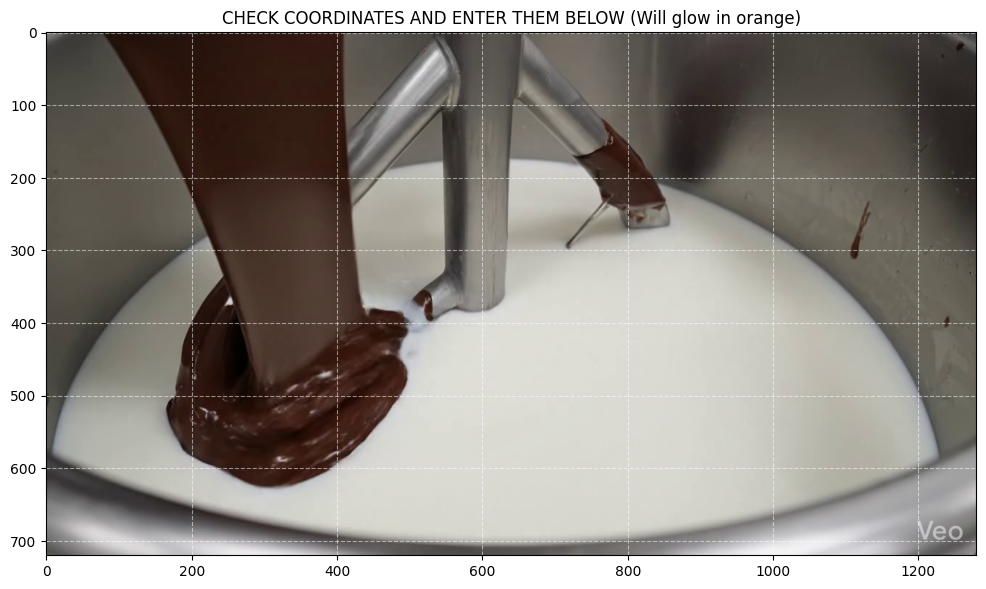

⏳ Generating orange selection...PLEASE BE PATIENT!!!!!!!


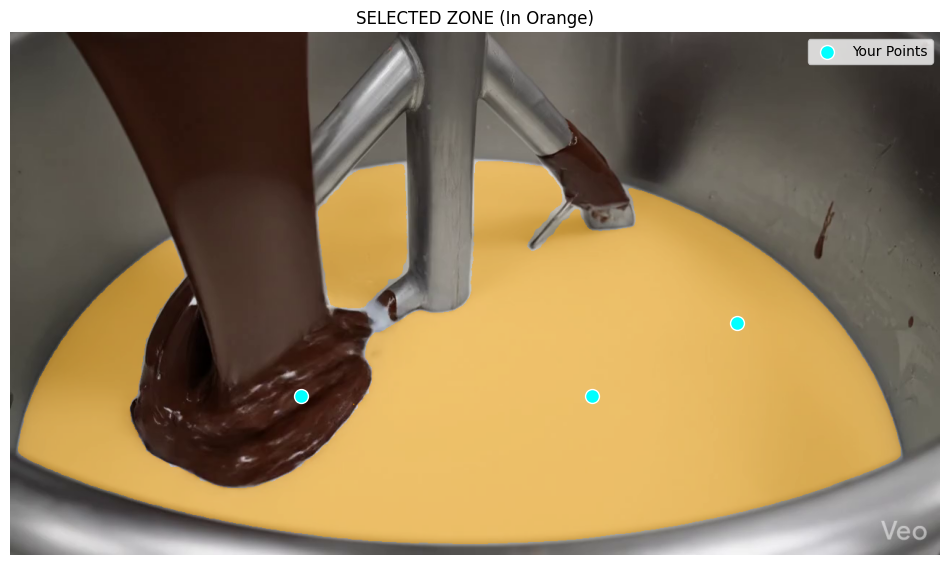

✅ If the orange covers the liquid well (and not the blades/background), proceed to Step 3.


In [ ]:
# @title 2 SEGMENTATION ALTERNATIVE. Material Coordinates (ORANGE Visualization)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. Get base frame
cap = cv2.VideoCapture(video_path)
ret, frame_bgr = cap.read()
cap.release()
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

# Display image with grid to identify coordinates
plt.figure(figsize=(12, 8))
plt.imshow(frame_rgb)
plt.grid(True, color='white', linestyle='--', alpha=0.5)
plt.title("CHECK COORDINATES AND ENTER THEM BELOW (Will glow in orange)")
plt.show()

# Widgets for coordinate input (Added a 3rd point for higher precision)
p1_x = widgets.IntText(value=400, description='P1 X:')
p1_y = widgets.IntText(value=500, description='P1 Y:')
p2_x = widgets.IntText(value=800, description='P2 X:')
p2_y = widgets.IntText(value=500, description='P2 Y:')
p3_x = widgets.IntText(value=600, description='P3 X:')
p3_y = widgets.IntText(value=400, description='P3 Y:')

btn_segment = widgets.Button(description="Generate Orange Mask", button_style='warning')

def execute_ai(b):
    global analysis_mask
    print("⏳ Generating orange selection...PLEASE BE PATIENT!!!!!!!")

    # User-defined points
    input_pts = np.array([[p1_x.value, p1_y.value], [p2_x.value, p2_y.value], [p3_x.value, p3_y.value]])
    input_lbls = np.array([1, 1, 1])

    predictor.set_image(frame_rgb)
    masks, scores, _ = predictor.predict(
        point_coords=input_pts,
        point_labels=input_lbls,
        multimask_output=True
    )

    # Select the best mask
    mask = masks[np.argmax(scores)]
    analysis_mask = (mask * 255).astype(np.uint8)

    # --- ORANGE VISUALIZATION ---
    # Create an orange layer (RGB: 255, 165, 0)
    orange_overlay = np.zeros_like(frame_rgb)
    orange_overlay[:] = [255, 165, 0]

    # Combine original image with the orange layer using the mask
    result_img = frame_rgb.copy()
    alpha = 0.5 # Color intensity (50% orange)

    # Apply orange only where mask is 255 (selected)
    idx = (analysis_mask > 0)
    result_img[idx] = cv2.addWeighted(frame_rgb[idx], 1-alpha, orange_overlay[idx], alpha, 0).reshape(-1, 3)

    # Show final result
    plt.figure(figsize=(12, 8))
    plt.imshow(result_img)
    # Plot user input points for reference
    plt.scatter(input_pts[:, 0], input_pts[:, 1], color='cyan', marker='o', edgecolors='white', s=100, label='Your Points')
    plt.title("SELECTED ZONE (In Orange)")
    plt.legend()
    plt.axis('off')
    plt.show()

    print("✅ If the orange covers the liquid well (and not the blades/background), proceed to Step 3.")

btn_segment.on_click(execute_ai)
display(widgets.VBox([
    widgets.HBox([p1_x, p1_y]),
    widgets.HBox([p2_x, p2_y]),
    widgets.HBox([p3_x, p3_y]),
    btn_segment
]))

⚡ Processing FLUID/DOUGH... (Step size: 15)
✅ Done! Video saved as 'miranda_kinetic_output.mp4'

📥 Downloading Kinetic Heatmap Video...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

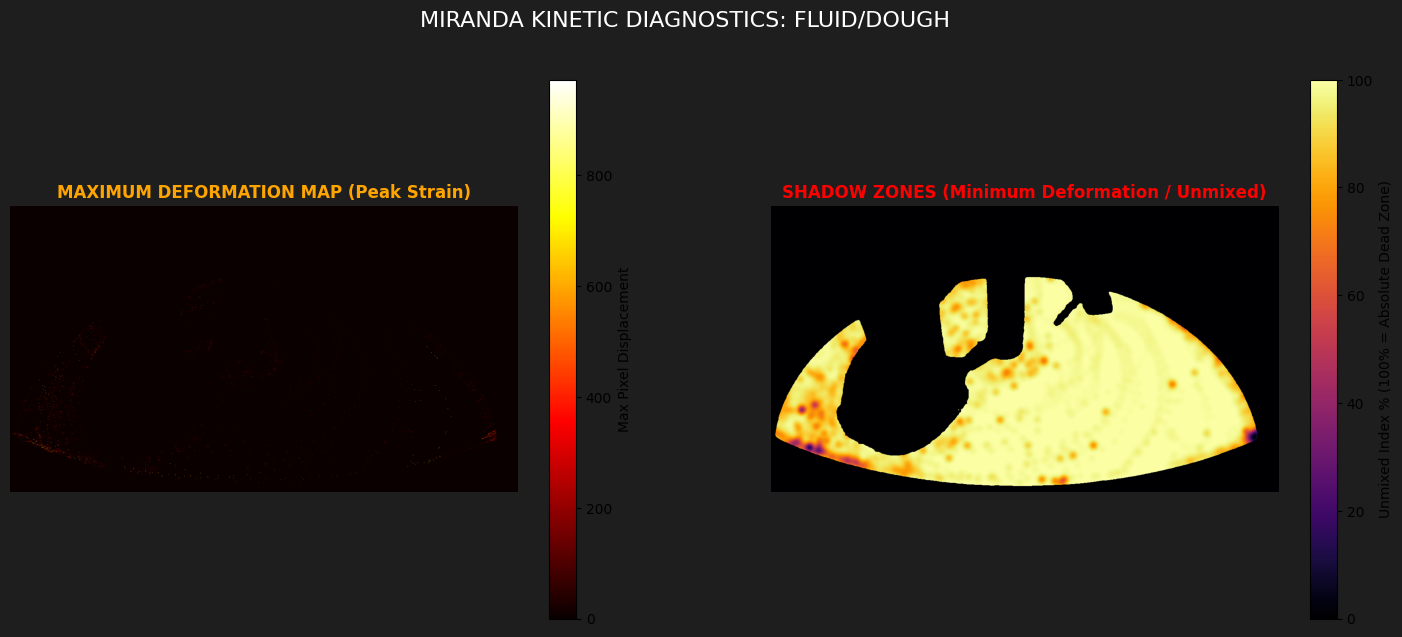

In [ ]:
# @title 🚀 3 Standard Continuous Heatmap (v2.9.0 - MINIMUM DEFORMATION CRITERION)
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# --- 0. SMART DEPENDENCY BRIDGE (AUTO-FIX) ---
if 'grid_density' not in globals():
    grid_density = 15

if 'ctx' not in globals():
    ctx = {'material': 'fluid/dough', 'type': 'stirring'}

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
if fps == 0 or np.isnan(fps): fps = 30

if 'points_list' not in globals() or len(points_list) == 0:
    _grid_y, _grid_x = np.mgrid[grid_density:height-grid_density:grid_density, grid_density:width-grid_density:grid_density]
    _all_pts = np.vstack((_grid_x.flatten(), _grid_y.flatten())).T

    if 'analysis_mask' in globals() and analysis_mask is not None:
        valid_pts = [pt for pt in _all_pts if analysis_mask[int(pt[1]), int(pt[0])] > 0]
        points_list = np.array(valid_pts, dtype=np.float32).reshape(-1, 1, 2)
        if len(points_list) == 0: points_list = _all_pts.astype(np.float32).reshape(-1, 1, 2)
    else:
        points_list = _all_pts.astype(np.float32).reshape(-1, 1, 2)

if 'p_static_curr' not in globals() or len(p_static_curr) == 0:
    p_static_curr = points_list.copy()

# --- 1. STANDARD CONFIGURATION ---
step = grid_density
glow_size = step
persistence = 0.75
intensity_gain = 5.0

peak_map = np.zeros((height, width), dtype=np.float32)
smooth_heat_buffer = np.zeros((height, width), dtype=np.float32)

# NEW CRITERION: Cumulative Shear/Deformation Map
cumulative_shear_map = np.zeros((height, width), dtype=np.float32)

telemetry_log = []

out_heat = cv2.VideoWriter('miranda_kinetic_output.mp4', cv2.VideoWriter_fourcc(*'mp4v'), int(fps), (width, height))

p_curr = np.array(points_list, dtype=np.float32)
origin = p_curr.copy()
p_prev = p_curr.copy()
old_gray_dyn = None

print(f"⚡ Processing {ctx['material'].upper()}... (Step size: {step})")

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if old_gray_dyn is None:
        old_gray_dyn = frame_gray.copy()
        continue

    camera_shift = np.array([0.0, 0.0], dtype=np.float32)
    if frame_idx % 2 == 0:
        p_static_next, st_s, _ = cv2.calcOpticalFlowPyrLK(old_gray_dyn, frame_gray, p_static_curr, None, winSize=(15,15))
        if p_static_next is not None and len(p_static_next[st_s == 1]) > 0:
            camera_shift = np.mean(p_static_next[st_s == 1] - p_static_curr[st_s == 1], axis=0)

    if len(p_curr) > 0:
        p1, st, _ = cv2.calcOpticalFlowPyrLK(old_gray_dyn, frame_gray, p_curr, None, winSize=(21,21), maxLevel=2)

        if p1 is not None:
            status = st.reshape(-1)
            frame_raw_heat = np.zeros((height, width), dtype=np.float32)
            v_mags, v_x, v_y = [], [], []

            for i, (new, org, prev) in enumerate(zip(p1, origin, p_prev)):
                if status[i]:
                    nx, ny = new.ravel()
                    motion = (new - prev) - camera_shift
                    vx, vy = motion[0] * fps
                    v_inst = np.sqrt(vx**2 + vy**2)

                    if 0 <= int(ny) < height and 0 <= int(nx) < width:
                        val = float(min(v_inst * intensity_gain, 255))
                        cv2.circle(frame_raw_heat, (int(nx), int(ny)), glow_size, val, -1)

                        # --- BETTER CRITERION FOR SHADOW ZONES ---
                        # Integrate (sum) the total deformation (shear/flow) per pixel over time
                        cumulative_shear_map[int(ny), int(nx)] += v_inst

                        if i % 6 == 0 and v_inst > 15:
                            cv2.arrowedLine(frame, (int(nx), int(ny)), (int(nx + int(vx/15)), int(ny + int(vy/15))), (255, 255, 255), 1, tipLength=0.3)

                        peak_map[int(ny), int(nx)] = max(peak_map[int(ny), int(nx)], np.sqrt(np.sum((new - org)**2)))
                        v_mags.append(v_inst); v_x.append(vx); v_y.append(vy)

        smooth_heat_buffer = cv2.addWeighted(smooth_heat_buffer, persistence, frame_raw_heat, 1.0 - persistence, 0)

        blur_radius = (step * 3) | 1
        heat_blurred = cv2.GaussianBlur(smooth_heat_buffer, (blur_radius, blur_radius), 0)
        heat_8bit = cv2.normalize(heat_blurred, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        cmap = cv2.COLORMAP_MAGMA if ctx.get('material') == 'liquid' else cv2.COLORMAP_JET
        heat_color = cv2.applyColorMap(heat_8bit, cmap)

        mask = cv2.threshold(heat_8bit, 10, 255, cv2.THRESH_BINARY)[1]
        heat_final = cv2.bitwise_and(heat_color, heat_color, mask=mask)

        combined = cv2.addWeighted(frame, 0.7, heat_final, 0.6, 0)
        out_heat.write(combined)

        if v_mags:
            telemetry_log.append({"Vel": np.mean(v_mags), "X": np.mean(v_x), "Y": np.mean(v_y)})

        p_curr = p1[status == 1].reshape(-1, 1, 2)
        p_prev = p_curr.copy()
        origin = origin[status == 1].reshape(-1, 1, 2)

    old_gray_dyn = frame_gray.copy()
    frame_idx += 1

cap.release()
out_heat.release()
print("✅ Done! Video saved as 'miranda_kinetic_output.mp4'")

# --- 5. FINALIZATION & VISUAL DIAGNOSTICS ---
try:
    from google.colab import files
    print("\n📥 Downloading Kinetic Heatmap Video...")
    files.download('miranda_kinetic_output.mp4')
except Exception as e:
    print(f"⚠️ Download failed. Find the file in the sidebar: miranda_kinetic_output.mp4")

# --- POST-PROCESSING FOR SHADOW ZONES (MINIMUM DEFORMATION) ---
zone_blur = (step * 3) | 1
smoothed_shear = cv2.GaussianBlur(cumulative_shear_map, (zone_blur, zone_blur), 0)

# Establish what the "valid" area is based on the Orange Mask
if 'analysis_mask' in globals() and analysis_mask is not None:
    valid_mask = (analysis_mask > 0)
    peak_map[~valid_mask] = 0
else:
    valid_mask = (smoothed_shear >= 0) # Apply to all pixels if no mask

# Find the maximum cumulative mixing/shear inside the valid area
max_shear = np.max(smoothed_shear[valid_mask]) if np.any(valid_mask) else 1e-6

# Calculate Unmixed Index (100% = No deformation at all, 0% = Max deformation/Perfectly mixed)
shadow_zones = np.zeros_like(smoothed_shear)
shadow_zones[valid_mask] = 100 - ((smoothed_shear[valid_mask] / max_shear) * 100)
shadow_zones[~valid_mask] = 0 # Clean the background completely

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

im1 = ax1.imshow(peak_map, cmap='hot')
ax1.set_title("MAXIMUM DEFORMATION MAP (Peak Strain)", color='orange', fontweight='bold')
plt.colorbar(im1, ax=ax1, label="Max Pixel Displacement")
ax1.axis('off')

# Use 'inferno' to highlight the dead zones (higher values = brighter = worse mixing)
im2 = ax2.imshow(shadow_zones, cmap='inferno', vmin=0, vmax=100)
ax2.set_title("SHADOW ZONES (Minimum Deformation / Unmixed)", color='red', fontweight='bold')
plt.colorbar(im2, ax=ax2, label="Unmixed Index % (100% = Absolute Dead Zone)")
ax2.axis('off')

plt.suptitle(f"MIRANDA KINETIC DIAGNOSTICS: {ctx.get('material', 'MATERIAL').upper()}", fontsize=16, color='white')
fig.patch.set_facecolor('#1e1e1e') # Dark mode background
plt.show()

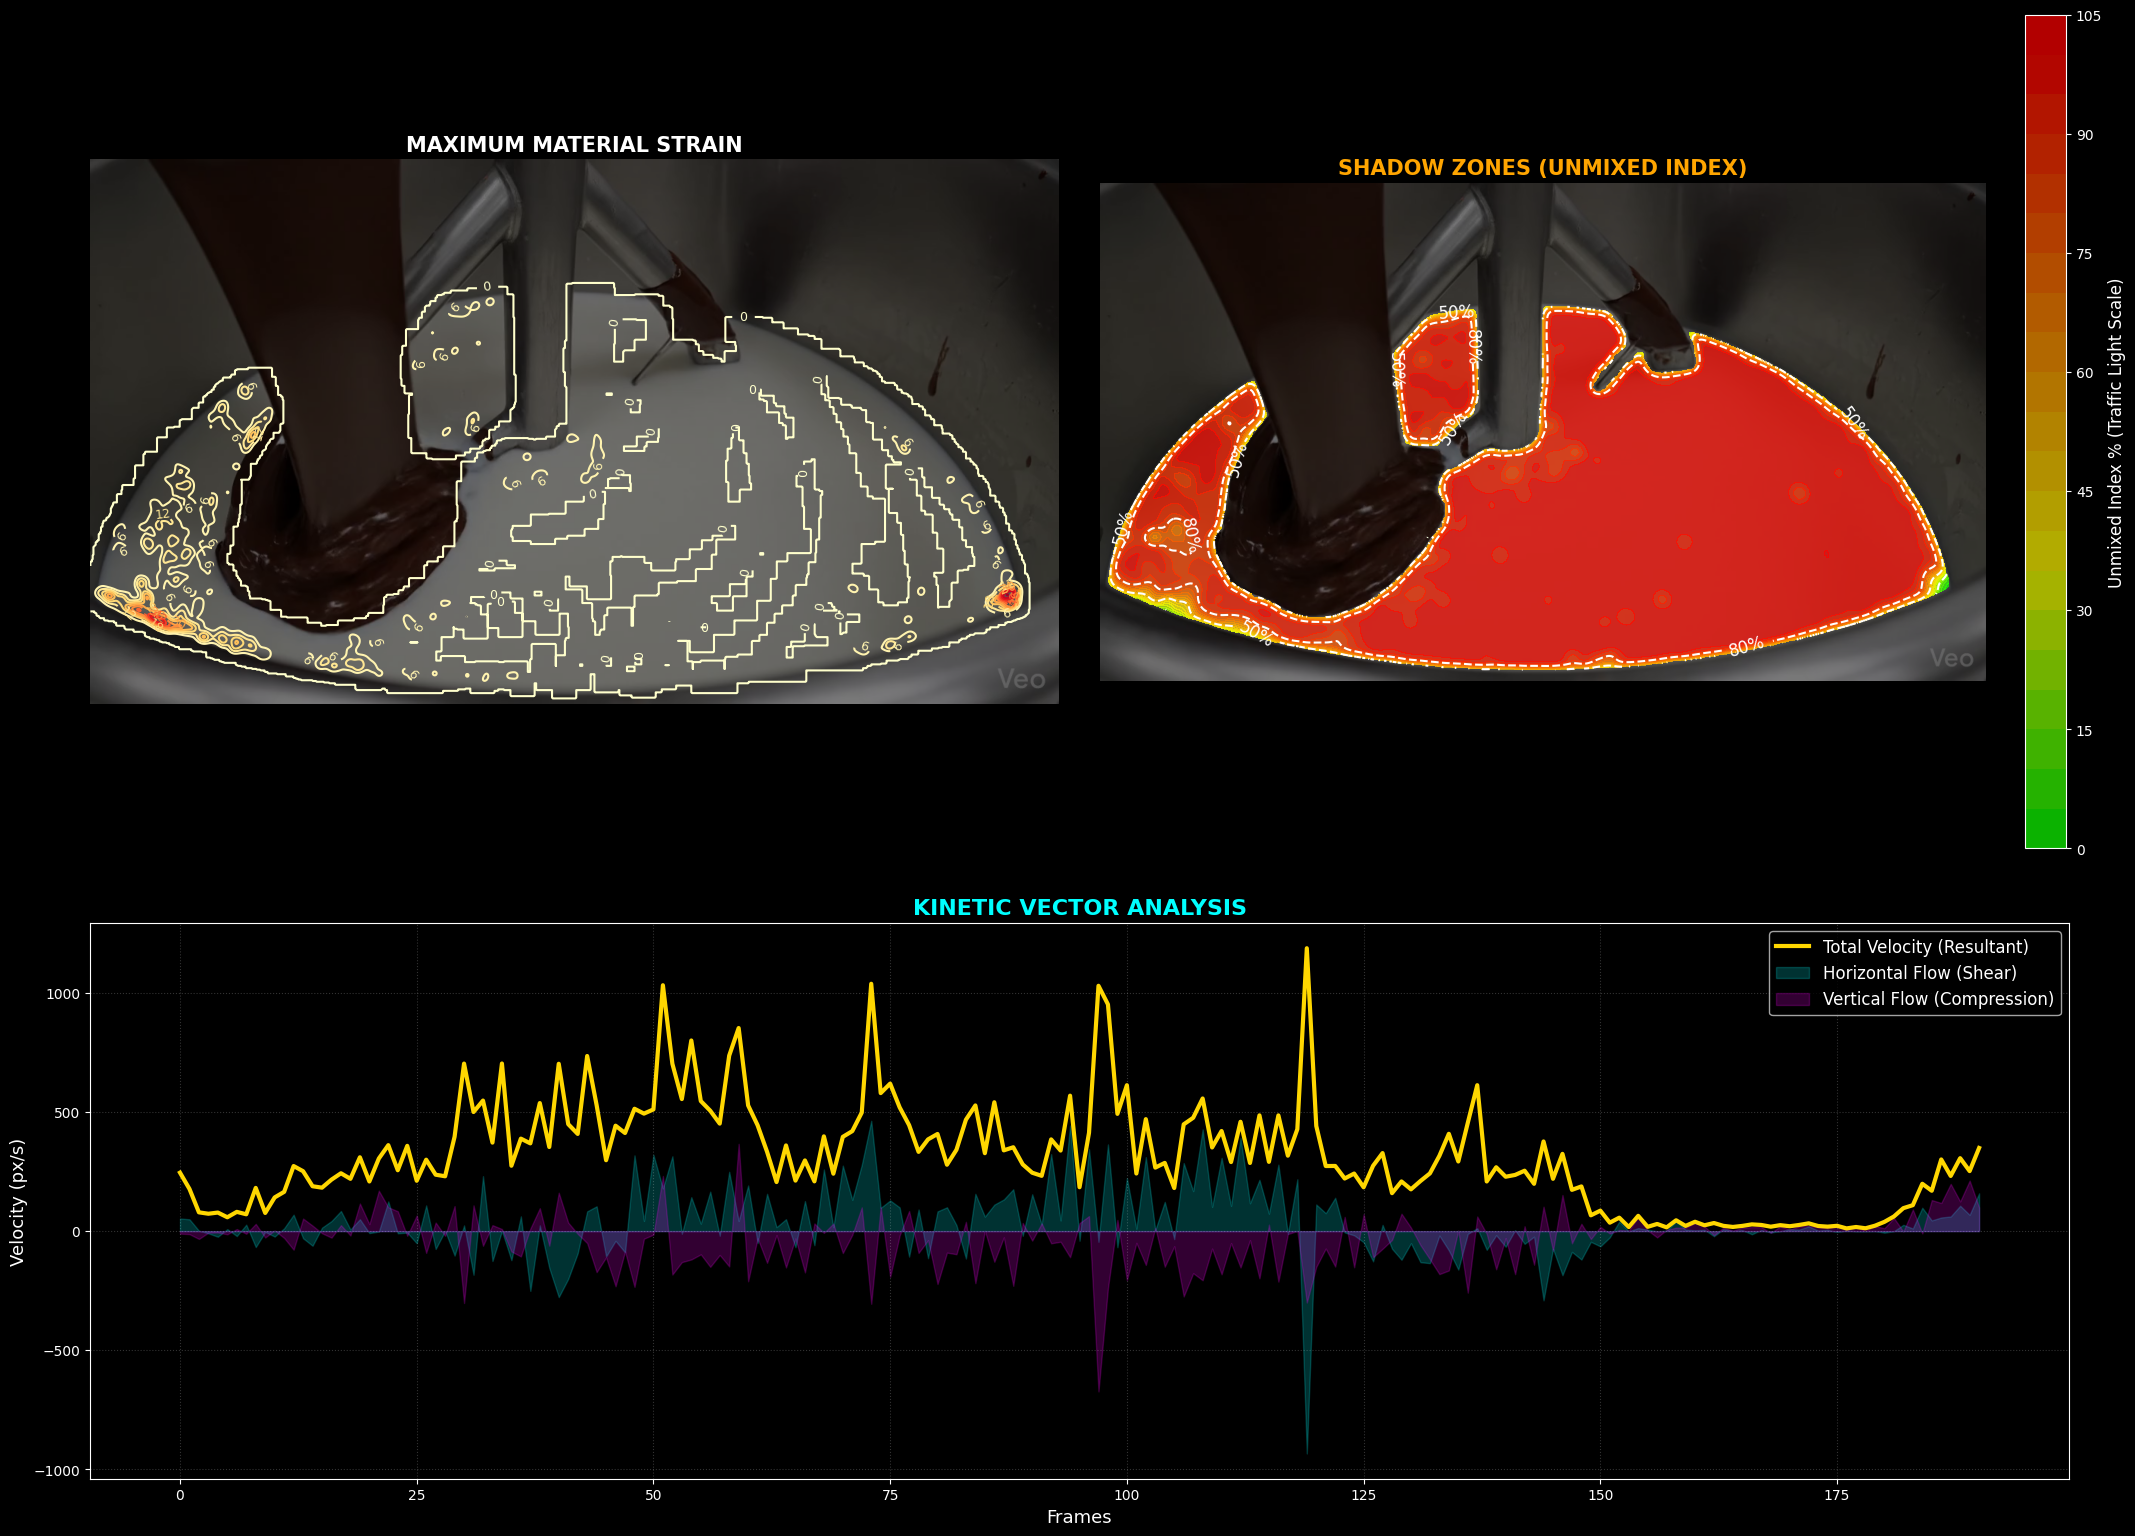


═════════════════════════════════════════════════════════════════════════════════════
 🏭 MIRANDA OPERATOR REPORT: MIXING QUALITY & HOMOGENEITY
═════════════════════════════════════════════════════════════════════════════════════
 ‣ ANALYSIS MODE:      STIRRING
 ‣ MATERIAL TARGET:    FLUID/DOUGH

 📊 SPATIAL DISTRIBUTION BREAKDOWN (Inside Vessel):
    🟢 EXCELLENT MIXING (0-20% Unmixed):     0.1% of volume
    🟡 MODERATE MIXING (20-50% Unmixed):    0.4% of volume
    🟠 SLUGGISH FLOW (50-80% Unmixed):      3.3% of volume
    🔴 DEAD ZONES (>80% Unmixed):          96.2% of volume

 ⚙️ KINETIC BEHAVIOR:
    ‣ Dominant Motion:    Vertical / Compressive Mixing
    ‣ Kinetic Stability:  28.1% (Consistency of speed)

 ⚠️ OPERATOR DIAGNOSIS:
    [!] CRITICAL WARNING: Severe dead zones detected.
        ACTION REQUIRED: Consider modifying impeller speed, checking for wall buildup, or adjusting blade geometry.
═════════════════════════════════════════════════════════════════════════════════════



In [ ]:
# @title 📊 4. FINAL VISUAL SCIENTIFIC REPORT & SHADOW ZONES (2-TIER DASHBOARD)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

# --- 0. SMART DEPENDENCY BRIDGE ---
if 'telemetry_log' in globals() and len(telemetry_log) > 0:
    df = pd.DataFrame(telemetry_log)
else:
    df = pd.DataFrame({"Vel": [0], "X": [0], "Y": [0]})

if 'shadow_zones' not in globals():
    shadow_zones = np.zeros((height, width), dtype=np.float32)
if 'valid_mask' not in globals():
    if 'analysis_mask' in globals() and analysis_mask is not None:
        valid_mask = (analysis_mask > 0)
    else:
        valid_mask = np.ones((height, width), dtype=bool)

# --- 1. COLOR ALIGNMENT (TRAFFIC LIGHT SYSTEM) ---
traffic_colors = ["#00FF00", "#FFFF00", "#FF8C00", "#FF0000"]
nodes = [0.0, 0.35, 0.65, 1.0]
traffic_cmap = LinearSegmentedColormap.from_list("TrafficLight", list(zip(nodes, traffic_colors)))

# --- 2. VISUAL DASHBOARD (2-TIER LAYOUT) ---
plt.style.use('dark_background')
fig = plt.figure(figsize=(22, 16)) # Taller figure to fit the bottom panel
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.2, 0.8]) # Top row taller than bottom row

# Extract Background
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
ret, f_bg = cap.read()
cap.release()
if ret: f_bg_rgb = cv2.cvtColor(f_bg, cv2.COLOR_BGR2RGB)
else: f_bg_rgb = np.zeros((height, width, 3), dtype=np.uint8)

# ---------------------------------------------------------
# TOP LEFT PANEL: ORIGINAL KINETIC CONTOUR MAP (ANNEX)
# ---------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(f_bg_rgb, alpha=0.5)

if ctx.get('material') == 'liquid':
    Z_orig = cv2.GaussianBlur(stagnation_map, (31, 31), 0)
    title_orig = "ORIGINAL STAGNATION (DEAD SPACES)"
    cmap_orig = 'magma'
else:
    Z_orig = cv2.GaussianBlur(peak_map, (31, 31), 0)
    title_orig = "MAXIMUM MATERIAL STRAIN"
    cmap_orig = 'YlOrRd'

contours_orig = ax1.contour(Z_orig, levels=12, cmap=cmap_orig, linewidths=1.5)
ax1.clabel(contours_orig, inline=True, fontsize=9, fmt='%.0f')
ax1.set_title(title_orig, color='white', fontweight='bold', fontsize=15)
ax1.axis('off')

# ---------------------------------------------------------
# TOP RIGHT PANEL: SHADOW ZONES (TRAFFIC LIGHT SCALE)
# ---------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(f_bg_rgb, alpha=0.5)

Z_shadow = cv2.GaussianBlur(shadow_zones, (45, 45), 0)
Z_shadow_masked = np.copy(Z_shadow)
Z_shadow_masked[~valid_mask] = np.nan

im2 = ax2.contourf(Z_shadow_masked, levels=20, cmap=traffic_cmap, alpha=0.7, vmin=0, vmax=100)
contours_shadow = ax2.contour(Z_shadow_masked, levels=[20, 50, 80], colors='white', linewidths=1.5, linestyles='dashed')
ax2.clabel(contours_shadow, inline=True, fontsize=12, fmt='%.0f%%', colors='white')

ax2.set_title("SHADOW ZONES (UNMIXED INDEX)", color='orange', fontweight='bold', fontsize=15)
cbar = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label("Unmixed Index % (Traffic Light Scale)", color='white', size=12)
ax2.axis('off')

# ---------------------------------------------------------
# BOTTOM PANEL: DIRECTIONAL KINETIC ANALYSIS (FULL WIDTH)
# ---------------------------------------------------------
ax3 = fig.add_subplot(gs[1, :]) # This makes the plot span across both columns
ax3.plot(df["Vel"], color='gold', label='Total Velocity (Resultant)', lw=3)
ax3.fill_between(range(len(df)), df["X"], color='cyan', alpha=0.2, label='Horizontal Flow (Shear)')
ax3.fill_between(range(len(df)), df["Y"], color='magenta', alpha=0.2, label='Vertical Flow (Compression)')
ax3.set_title("KINETIC VECTOR ANALYSIS", color='cyan', fontweight='bold', fontsize=16)
ax3.set_xlabel("Frames", fontsize=13)
ax3.set_ylabel("Velocity (px/s)", fontsize=13)
ax3.legend(loc='upper right', fontsize=12)
ax3.grid(alpha=0.2, linestyle=':')

plt.tight_layout(pad=3.0)
plt.show()

# --- 3. AUTOMATIC OPERATOR REPORT ---
print("\n" + "═"*85)
print(" 🏭 MIRANDA OPERATOR REPORT: MIXING QUALITY & HOMOGENEITY")
print("═"*85)
print(f" ‣ ANALYSIS MODE:      {ctx.get('type', 'UNKNOWN').upper()}")
print(f" ‣ MATERIAL TARGET:    {ctx.get('material', 'UNKNOWN').upper()}")

# Calculate zonal distribution inside the valid container area
valid_pixels = shadow_zones[valid_mask]
total_valid = len(valid_pixels)

if total_valid > 0:
    zone_excellent = np.sum(valid_pixels <= 20) / total_valid * 100
    zone_moderate  = np.sum((valid_pixels > 20) & (valid_pixels <= 50)) / total_valid * 100
    zone_sluggish  = np.sum((valid_pixels > 50) & (valid_pixels <= 80)) / total_valid * 100
    zone_dead      = np.sum(valid_pixels > 80) / total_valid * 100
else:
    zone_excellent = zone_moderate = zone_sluggish = zone_dead = 0.0

print("\n 📊 SPATIAL DISTRIBUTION BREAKDOWN (Inside Vessel):")
print(f"    🟢 EXCELLENT MIXING (0-20% Unmixed):   {zone_excellent:>5.1f}% of volume")
print(f"    🟡 MODERATE MIXING (20-50% Unmixed):  {zone_moderate:>5.1f}% of volume")
print(f"    🟠 SLUGGISH FLOW (50-80% Unmixed):    {zone_sluggish:>5.1f}% of volume")
print(f"    🔴 DEAD ZONES (>80% Unmixed):         {zone_dead:>5.1f}% of volume")

print("\n ⚙️ KINETIC BEHAVIOR:")
dominance = "Rotational / Shear Mixing" if abs(df['X'].mean()) > abs(df['Y'].mean()) else "Vertical / Compressive Mixing"
print(f"    ‣ Dominant Motion:    {dominance}")
print(f"    ‣ Kinetic Stability:  {max(0, 100 - (df['Vel'].std()/(df['Vel'].mean()+1e-6)*100)):.1f}% (Consistency of speed)")

print("\n ⚠️ OPERATOR DIAGNOSIS:")
if zone_dead > 15.0:
    print("    [!] CRITICAL WARNING: Severe dead zones detected.")
    print("        ACTION REQUIRED: Consider modifying impeller speed, checking for wall buildup, or adjusting blade geometry.")
elif zone_sluggish > 30.0:
    print("    [!] ADVISORY: Large portions of the material are moving too slowly.")
    print("        ACTION REQUIRED: Verify if viscosity has increased or if mixing time needs extension.")
elif zone_excellent > 75.0:
    print("    [✓] OPTIMAL STATUS: The material exhibits excellent homogeneity and continuous flow.")
else:
    print("    [-] ACCEPTABLE STATUS: Mixing is within standard operational parameters. Monitor sluggish zones.")
print("═"*85 + "\n")

# 🔬 MIRANDA SCIENTIFIC: Industrial Rheology Interpretation (v2.4.7)

---

This report provides a physical and industrial explanation of the metrics calculated during the analysis. It incorporates **Backward Plateau Detection** to isolate the true rest state and a **Multivariate Industrial Fingerprint** for holistic quality assessment.

---

## 🌊 1. Fluid Rheology & Flow Dynamics (Liquids & Semi-Fluids)

For materials categorized as liquids, the focus shifts to internal resistance, flow stability, and molecular friction under active stirring.

* **Apparent Viscosity ($\eta$)**
    * **Calculation:** Normalized ratio of **Applied Force** to **Flow Velocity** ($\eta \propto F/v$).
    * **Industrial Meaning:** This represents "Fluid Thickness." In a factory setting, high viscosity directly correlates to the energy required to pump, stir, or fill containers. It is the primary metric for lubricants, syrups, and coatings.

* **Flow Consistency Index**
    * **Calculation:** The inverse of the coefficient of variation in flow speed ($1 - CV_{v}$).
    * **Industrial Meaning:** Measures the stability of the fluid's body. A high score (near 100%) indicates a homogeneous, stable fluid. Low scores warn of "lumping," phase separation, or uneven composition during processing.
* **Thixotropic Alert (Structural Thinning)**
    * **Calculation:** Analysis of the velocity slope ($dv/dt$) during the constant loading phase.
    * **Industrial Meaning:** Identifies if a fluid "thins out" as it is agitated. Essential for paints (to be easy to brush but not drip) and food sauces (to flow when squeezed but stay thick on the plate).

---

## 🍞 2. Viscoelastic Solids (Dough & Elastic Solids)

Evaluates "Mechanical Memory" and structural integrity through **Creep-Recovery** analysis.

* **Recovery Efficiency (Elasticity %)**
    * **Calculation:** $((d_{max} - d_{final}) / d_{max}) \cdot 100$, where $d_{final}$ is pinpointed via **Backward Plateau Sync** (The Yellow Line).
    * **Industrial Meaning:** Measures the material's "Memory." High recovery in dough indicates a strong, well-developed gluten network. In industrial foams, it indicates high-quality cross-linking.

* **Stabilization Time (The Yellow Line)**
    * **Calculation:** $T_{rest} - T_{peak}$. The time elapsed from force removal to absolute mechanical equilibrium.
    * **Industrial Meaning:** Defines the "Snap-back" speed. Short times suggest high resilience; long times indicate high internal friction or viscous "sluggishness."
* **Tau ($\tau$) Relaxation Constant**
    * **Calculation:** Exponential decay constant $\ln(d - d_{final}) \propto -t/\tau$ calculated between the peak and the stability plateau.
    * **Industrial Meaning:** Quantifies molecular memory.
        * **Fast $\tau$ (<0.1s):** "Ultra-elastic" rebound (Spring-like).
        * **Slow $\tau$ (>2s):** "Stubborn" material (Plastic-like memory).
* **Tenacity (Work Energy Area)**
    * **Calculation:** **Simpson's Rule integration** of the area under the Displacement-Time curve ($\int d \, dt$).
    * **Industrial Meaning:** Total energy absorbed. High tenacity means the material is "tough" and resistant to mechanical tearing or over-processing.
* **Energy Hysteresis (Loss Index)**
    * **Calculation:** $(\text{Area}_{loading} - \text{Area}_{recovery}) / \text{Area}_{loading} \cdot 100$.
    * **Industrial Meaning:** Measures energy dissipated as heat or internal damage. Low hysteresis (<15%) means high elastic efficiency (Resilience). High hysteresis suggests the material is better at absorbing shocks.

---

## 🕸️ 3. Multivariate Industrial Fingerprint (Radar Chart)

The final stage consolidates all physical dimensions into a single visual "Fingerprint."

* **Symmetry & Shape Interpretation:** * **Balanced Profile:** A large, symmetrical polygon indicates a high-quality, viscoelastically balanced material (Ideal for Doughs).
    * **Viscous Dominance:** Stretching towards "Viscosity" and "Consistency" with low "Elasticity" (Ideal for Industrial Liquids).
    * **Elastic Dominance:** Stretching towards "Elasticity" and "Memory" (Ideal for Springs and Rubber).
* **Data Reliability ($R^2$):** * Evaluates the statistical fit of the relaxation curve. High values (>0.90) confirm that the material is behaving according to predictable rheological laws.


---
*Generated by Miranda Scientific Pro Engine v2.4.7* *Backward Plateau & Multivariate Analysis Suite*

# 🔬 MIRANDA SCIENTIFIC: Advanced Industrial Rheology Interpretation (v2.3)

---

This report provides a physical and industrial explanation of the metrics calculated by the **Miranda Scientific Pro** engine. It incorporates advanced **Texture Profile Analysis (TPA)**, **Energy Hysteresis**, and **Global Motion Compensation (GMC)** to ensure laboratory-grade accuracy by isolating material behavior from environmental noise.

---

## 🛡️ 0. Signal Integrity & Stabilization

Before calculating rheological properties, Miranda ensures the data is scientifically valid.

* **Global Motion Compensation (GMC)**
    * **Calculation:** Tracking of static "Anchor Points" in the background to calculate the vector $\vec{V}_{camera}$. This is subtracted from material motion: $\vec{V}_{corrected} = \vec{V}_{raw} - \vec{V}_{camera}$.
    * **Meaning:** Filters out tripod vibrations, table tremors, or camera jitter. It ensures that the calculated velocity represents *only* the material's internal flow.

---

## 🌊 1. Non-Solid Materials (Liquids & Doughs)

For fluids and semi-fluids, the focus is on flow dynamics, resistance, and mixing homogeneity.

* **Relative Viscosity ($\eta$)**
    * **Calculation:** Ratio of applied **Force** to **Average Stabilized Velocity** ($\eta \propto F/v_{avg}$).
    * **Meaning:** Represents internal friction. High viscosity indicates a "thicker" material. Now stabilized by GMC to prevent overestimation due to camera shake.
    

* **Consistency Index**
    * **Calculation:** The mathematical inverse of the Relative Viscosity ($1/\eta$).
    * **Meaning:** Measures the structural "body." Critical for ensuring shelf-stability and mouthfeel consistency in industrial batches.

* **Flow Uniformity (Industrial Mixing)**
    * **Calculation:** $1 - (\text{std}(v)/\text{mean}(v))$, calculated across all $N$ tracking points.
    * **Meaning:** High values (close to 100%) indicate a perfectly homogeneous mix. Low values detect lumps, air pockets, or "dead zones" in the mixing process.

---

## 🍞 2. Viscoelastic Solids & Texture Profile Analysis (TPA)

Miranda evaluates "structural memory," energy dissipation, and mechanical durability.

* **Tau ($\tau$) Relaxation Time**
    * **Calculation:** Obtained via **Exponential Decay Regression** during the post-peak phase: $d(t) = d_{final} + (d_{max} - d_{final}) \cdot e^{-t/\tau}$.
    * **Meaning:** The "Memory Constant." It defines how long the material takes to relax. A high $\tau$ indicates a solid-like "stubborn" structure; a low $\tau$ indicates a fluid-like "lazy" relaxation.
    

* **Energy Hysteresis (Loss Index)**
    * **Calculation:** The difference between **Loading Work** (Area under compression) and **Recovery Energy** (Area under return), expressed as a percentage.
    * **Meaning:** Quantifies internal energy dissipation. High Hysteresis (>40%) suggests internal structural damage, high friction, or plastic flow. Low Hysteresis suggests high elastic efficiency (resilience).
    

* **Hardness (Peak Force)**
    * **Calculation:** $v_{max} \cdot F$.
    * **Meaning:** Maximum resistance to the first impact. Correlates to the "hardness" of a solid or the "stiffness" of a dough.

* **Cohesiveness (Internal Bonding)**
    * **Calculation:** Ratio of energy storage: $\text{Area}_{loading} / (\text{Area}_{loading} + \text{Area}_{recovery})$.
    * **Meaning:** Measures how well the internal structure stays "glued" together. Critical for predicting if a material will crumble or maintain its integrity during processing.

* **Elasticity (Recovery %)**
    * **Calculation:** $((d_{max} - d_{final}) / d_{max}) \cdot 100$.
    * **Meaning:** The ability to return to the original shape. A high percentage indicates a strong elastic network (e.g., a well-developed gluten matrix in bread).

---

## 📊 3. Statistical Reliability & Accuracy

* **Spatial Variability Bands**
    * **Calculation:** Real-time Standard Deviation visualized as shaded areas.
    * **Meaning:** Narrow bands confirm a **Homogeneous Sample**. Wide bands alert the user to local defects or non-uniform deformation.

* **95% Confidence Interval (CI) & R² Fit**
    * **Calculation:** Computed via t-Student distribution and Least Squares for the Tau regression.
    * **Meaning:** Provides the margin of error. The **R² value** indicates how perfectly the material follows the Viscoelastic Decay model.
    

[Image of the t-distribution and confidence intervals]


---
*Generated by Miranda Scientific Pro Engine v2.3*
*Advanced Industrial Rheology & Motion Stabilization Suite*